In [93]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, sin, cos, exp
from utils import e_r_cpa_numerator, e_r_cpa_denominator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa
from refractiveindex import RefractiveIndexMaterial

# We try to re-create Figure 2 of the paper

In [355]:
omega_p = 7.9 # Bulk plasma frequency of Gold in eV
hbar_c = 6.58211957 * 3 * 10 #200 # in nanometers * eV
def gold_drude(omega_over_omega_p, omega_p=7.9, gamma_e=0.09):
    return 1-1/(omega_over_omega_p*(omega_over_omega_p+1j*gamma_e/omega_p))

# Equation 2 of the paper
def paper_method(l, epsilon, R, H, omega):
    rho_b = R*omega
    rho_a = (R+H)*omega
    eta_b = sqrt(epsilon)*rho_b
    eta_a = sqrt(epsilon)*rho_a

    rho_b_jlprime = spherical_jn(l, rho_b) + rho_b*spherical_jn(l, rho_b, derivative=True)
    eta_b_jlprime = spherical_jn(l, eta_b) + eta_b*spherical_jn(l, eta_b, derivative=True)
    eta_a_jlprime = spherical_jn(l, eta_a) + eta_a*spherical_jn(l, eta_a, derivative=True)

    rho_a_hlprime = hl1(l, rho_a) + rho_a*hl1prime(l, rho_a)
    eta_b_hlprime = hl1(l, eta_b) + eta_b*hl1prime(l, eta_b)
    eta_a_hlprime = hl1(l, eta_a) + eta_a*hl1prime(l, eta_a)

    D_l = eta_b_jlprime*hl1(l, eta_a)-eta_b_hlprime*spherical_jn(l, eta_a)
    C_l = spherical_jn(l, eta_b)*hl1(l, eta_a) - spherical_jn(l, eta_a)*hl1(l, eta_b)
    B_l = eta_b_jlprime * eta_a_hlprime - eta_a_jlprime * eta_b_hlprime
    A_l = spherical_jn(l, eta_b)*eta_a_hlprime - hl1(l, eta_b)*eta_a_jlprime

    beta_l = epsilon * (epsilon * rho_b_jlprime * C_l - spherical_jn(l, rho_b) * D_l)
    alpha_l = epsilon * rho_b_jlprime * A_l - spherical_jn(l, rho_b) * B_l

    LHS = hl1(l, rho_a) * alpha_l
    RHS = beta_l * rho_a_hlprime
    return LHS - RHS

# We first calculate everything for $l=1$. We need to play some tricks for higher angular momenta

In [237]:
K = 100
N = 200
l = 1
R = 6
Hs = linspace(0.1, 0.8, K) # Range of Rs (normalized value of b) used in the paper
omega_over_omega_ps_real = linspace(0.01, 0.4, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 0.5, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gamma_e = 0
gammas = np.zeros((K, N))
heatmap_data = np.zeros((K, N))
for (H_idx, H) in enumerate(Hs):
    if (H_idx % 10) == 0:
        print(H_idx)
    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    heatmap_data[H_idx, :] =  scattering_amplitudes.max(axis=1) # maximum across all imaginary values for the frequency
    gammas[H_idx, :] = omega_over_omega_ps_imag[scattering_amplitudes.argmax(axis=1)]

0
10
20
30
40
50
60
70
80
90


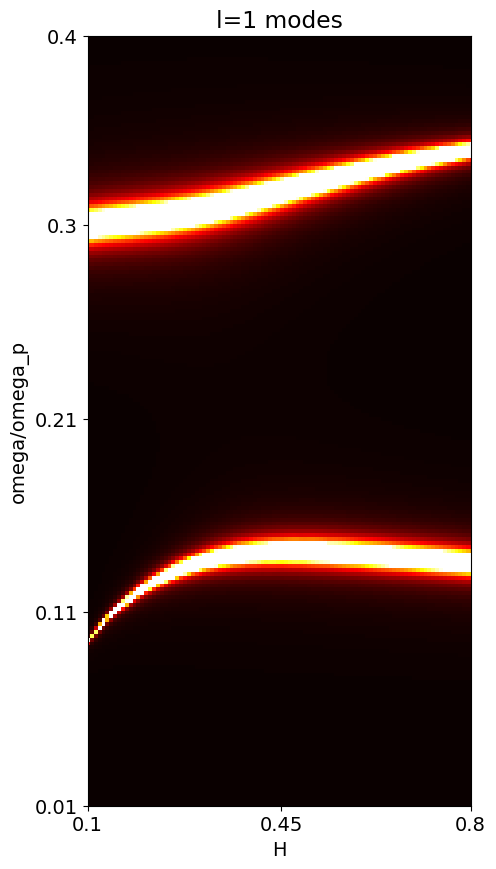

In [241]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(15,10))
ax.imshow(heatmap_data.T, cmap="hot", vmin=1, vmax=200, origin="lower");
ax.set_xticks([0, K/2, K-1], Hs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/4, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/4), round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("H")
ax.set_ylabel("omega/omega_p");
ax.set_title(f"l=1 modes");

# We first focus on the sphere-like modes

In [273]:
x, y = np.where(heatmap_data > 20) # Find where the modes are 
first_mode_idxs = np.where(omega_over_omega_ps_real[y] < 0.3) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

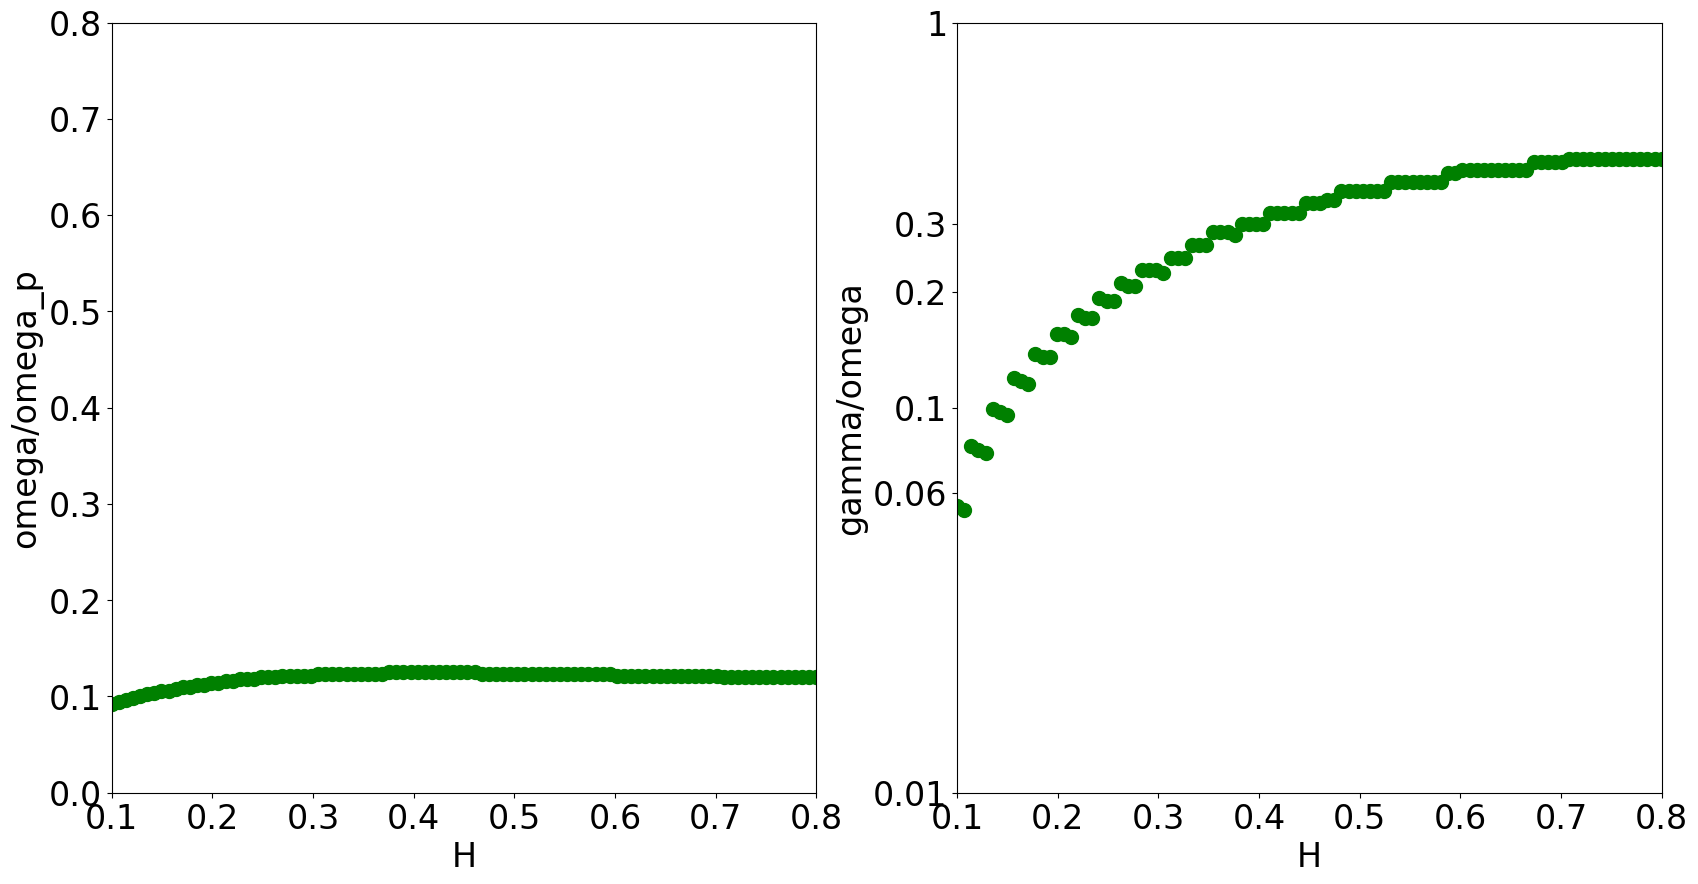

In [275]:
color = "green"
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x], omega_over_omega_ps_real[y], color=color, s=100);
ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8);

ax2.scatter(Hs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100);
ax2.set_xlabel("H")
ax2.set_yticks([log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(1)], [0.01, 0.06, 0.1, 0.2, 0.3, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);
ax2.set_ylim(log(0.01), log(1));

# We now make a smoother plot by zooming in on the dispersion

In [276]:
K = 100
N = 50
gamma_e = 0
optimized_gammas = np.zeros(Hs[x].shape[0])
optimized_omegas = np.zeros(Hs[x].shape[0])
optimized_Hs = np.zeros(Hs[x].shape[0])
for idx in range(0, Hs[x].shape[0]):
    if (idx % 10) == 0: 
        print(idx)
    H = Hs[x[idx]]
    starting_omega = omega_over_omega_ps_real[y[idx]]
    starting_gamma = gammas[x[idx], y[idx]]

    omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
    omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
    omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)

    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    max_idx = scattering_amplitudes.argmax()
    row, col = unravel_index(max_idx, (N, N))
    optimized_Hs[idx] = H
    optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
    optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

0
10
20
30
40
50
60
70
80
90


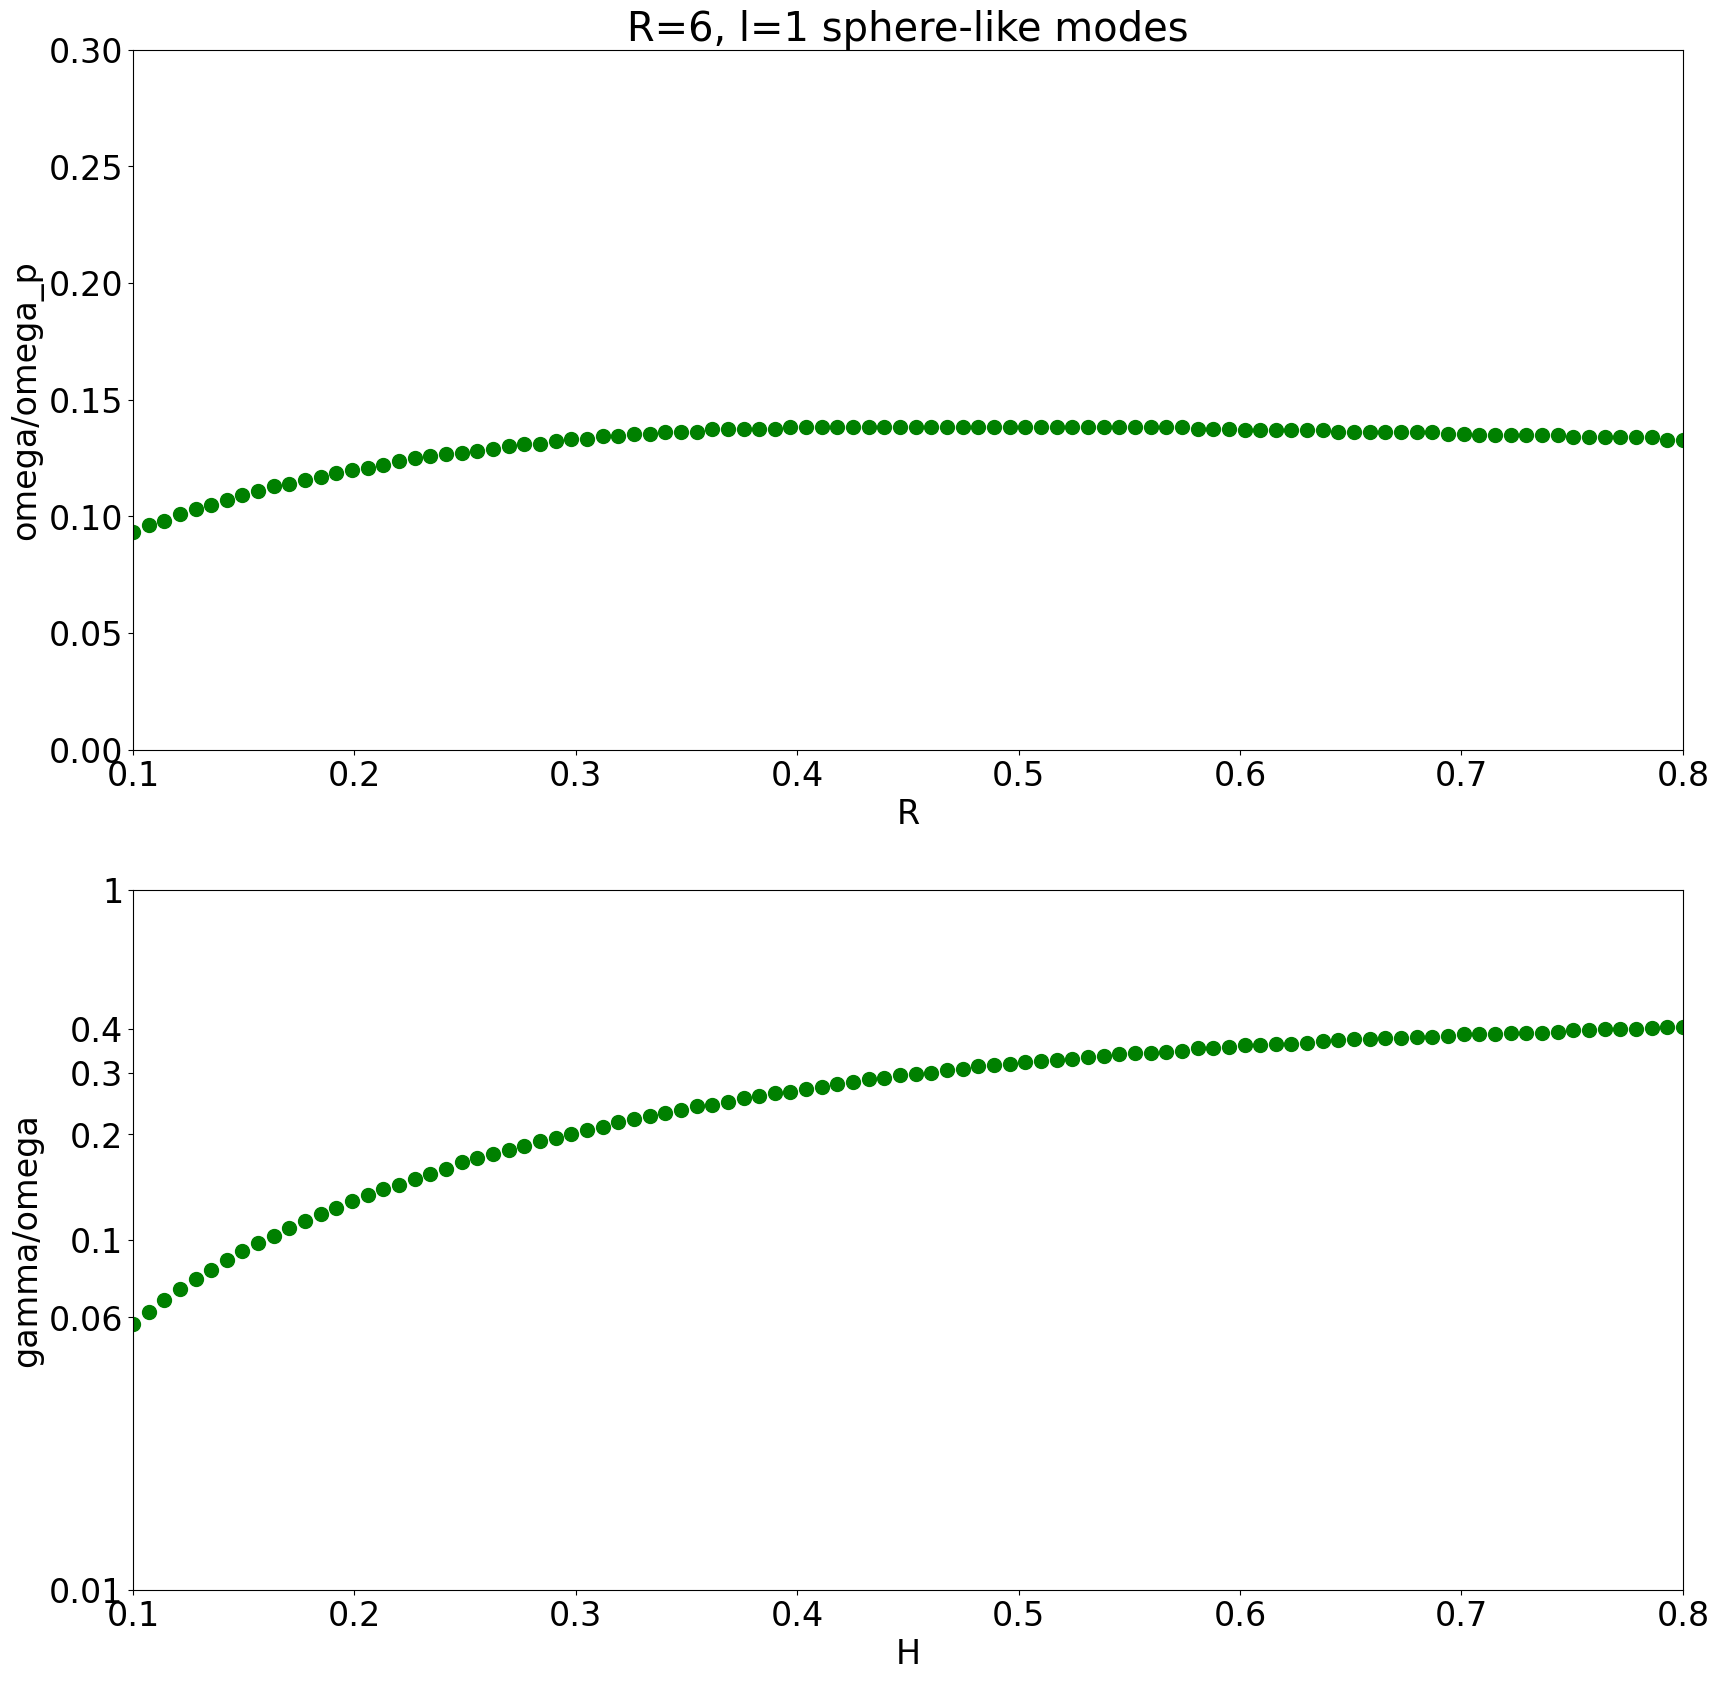

In [277]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
color = "green"
ax1.scatter(optimized_Hs, optimized_omegas, s=100, color=color)
ax2.scatter(optimized_Hs, log(optimized_gammas/optimized_omegas), s=100, color=color)
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.3);
ax2.set_yticks([log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(0.4), log(1)], [0.01, 0.06, 0.1, 0.2, 0.3, 0.4, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("H")
ax2.set_xlim(0.1, 0.8);
ax2.set_ylim(log(0.01), log(1));
ax1.set_title("R=6, l=1 sphere-like modes");

# Now we turn to the void-like modes 

In [278]:
x, y = np.where(heatmap_data > 20) # Find where the modes are 
first_mode_idxs = np.where(omega_over_omega_ps_real[y] > 1.5*optimized_omegas[x]) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

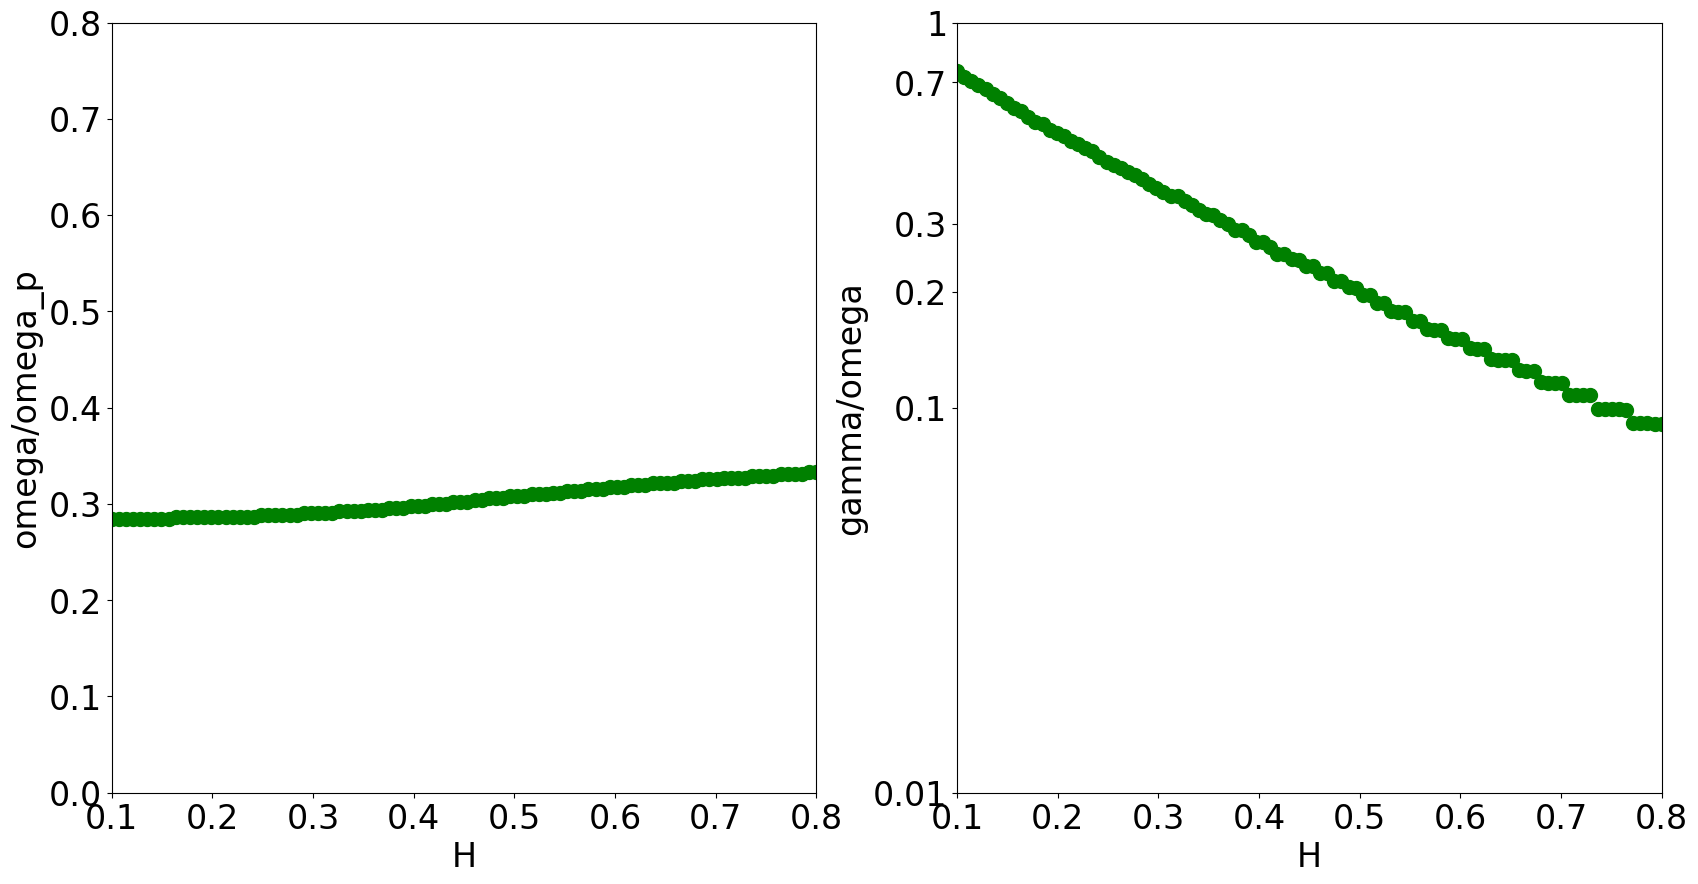

In [279]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x], omega_over_omega_ps_real[y], color=color, s=100);
ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8)

ax2.scatter(Hs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100);
ax2.set_xlabel("H")
ax2.set_yticks([log(0.01), log(0.1), log(0.2), log(0.3), log(0.7), log(1)], [0.01, 0.1, 0.2, 0.3, 0.7, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);
ax2.set_ylim(log(0.01), log(1));

# As before, we make this plot smoother

In [280]:
K = 100
N = 100
gamma_e = 0
optimized_gammas = np.zeros(Hs[x].shape[0])
optimized_omegas = np.zeros(Hs[x].shape[0])
optimized_Hs = np.zeros(Hs[x].shape[0])
for idx in range(0, Hs[x].shape[0]):
    if (idx % 25) == 0: 
        print(idx)
    H = Hs[x[idx]]
    starting_omega = omega_over_omega_ps_real[y[idx]]
    starting_gamma = gammas[x[idx], y[idx]]

    omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
    omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
    omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)

    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    max_idx = scattering_amplitudes.argmax()
    row, col = unravel_index(max_idx, (N, N))
    optimized_Hs[idx] = H
    optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
    optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

0
25
50
75


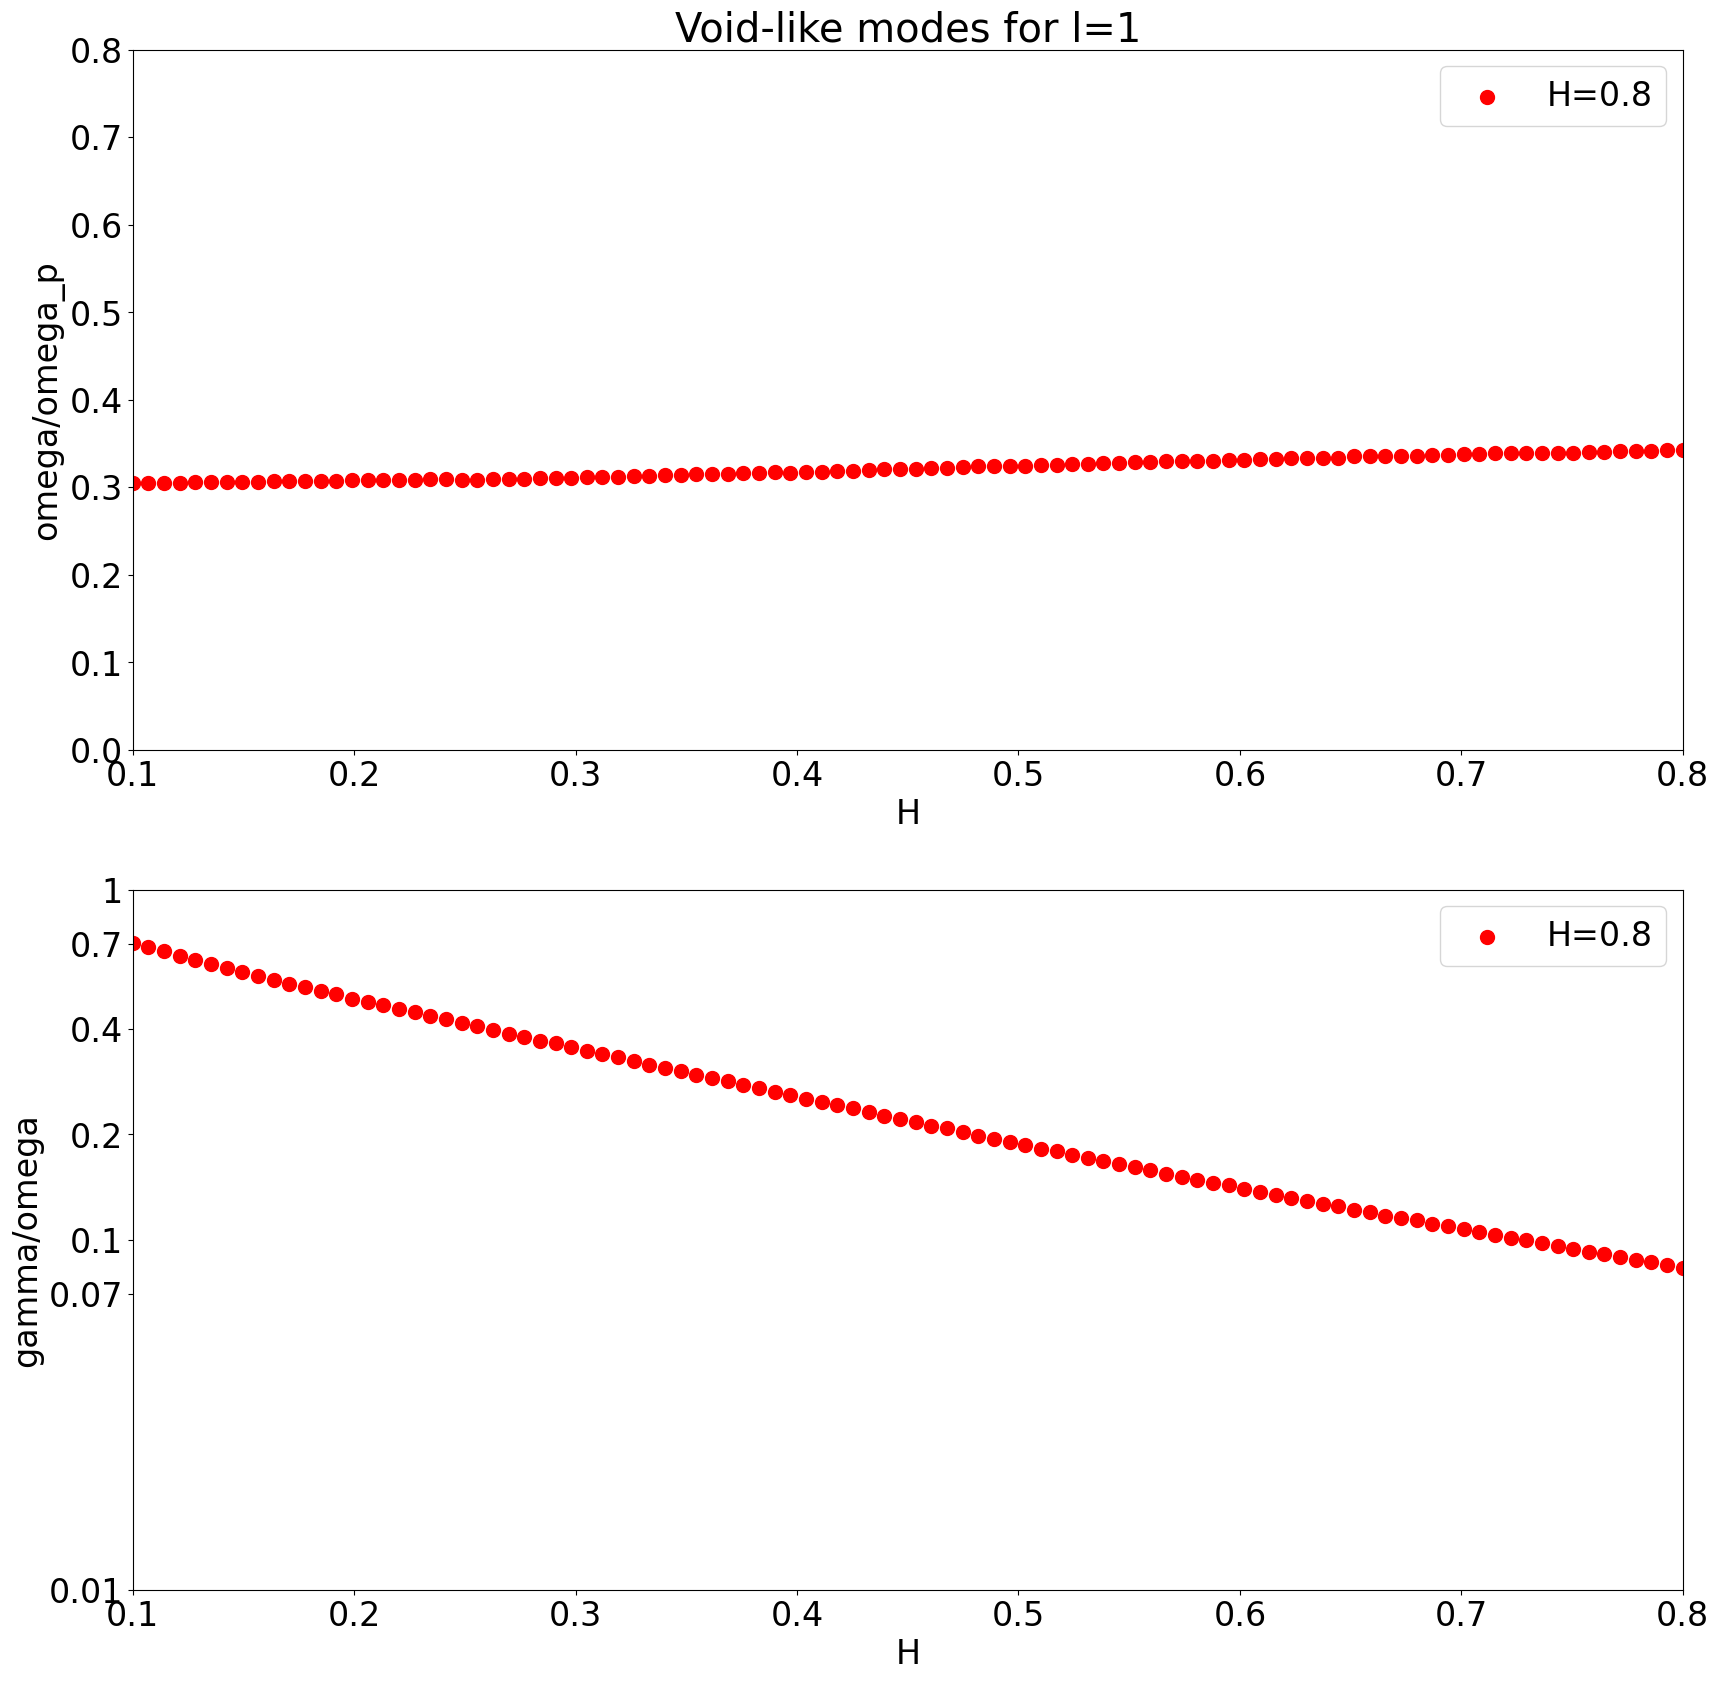

In [283]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
color = "red"
ax1.scatter(optimized_Hs, optimized_omegas, s=100, color=color, label=f"H={H}")
ax2.scatter(optimized_Hs, log(optimized_gammas/optimized_omegas), s=100, color=color, label=f"H={H}")

ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8);
ax1.legend();
ax2.set_yticks([log(0.01), log(0.07), log(0.1), log(0.2), log(0.4), log(0.7), log(1)], [0.01, 0.07, 0.1, 0.2, 0.4, 0.7, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("H")
ax2.set_xlim(0.1, 0.8);
ax2.set_ylim(log(0.01), log(1));
ax2.legend();
ax1.set_title("Void-like modes for l=1");


# Now we calculate for $l=2$

In [288]:
K = 100
N = 200
l = 2
R = 6
Hs = linspace(0.1, 0.8, K) # Range of Rs (normalized value of b) used in the paper
omega_over_omega_ps_real = linspace(0.01, 0.6, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 0.5, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gamma_e = 0
gammas = np.zeros((K, N))
heatmap_data = np.zeros((K, N))
for (H_idx, H) in enumerate(Hs):
    if (H_idx % 10) == 0:
        print(H_idx)
    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * l * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * l * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    heatmap_data[H_idx, :] =  scattering_amplitudes.max(axis=1) # maximum across all imaginary values for the frequency
    gammas[H_idx, :] = omega_over_omega_ps_imag[scattering_amplitudes.argmax(axis=1)]

0
10
20
30
40
50
60
70
80
90


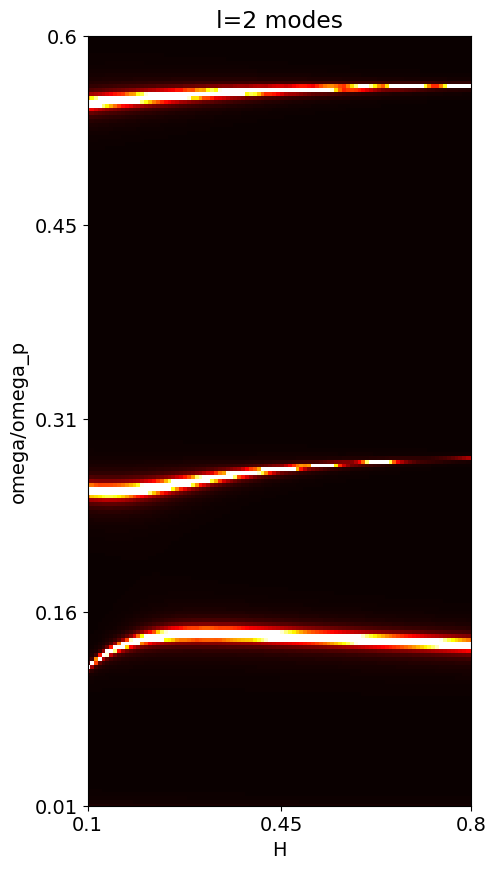

In [300]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(15,10))
ax.imshow(heatmap_data.T, cmap="hot", vmin=1, vmax=200, origin="lower");
ax.set_xticks([0, K/2, K-1], Hs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/4, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/4), round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("H")
ax.set_ylabel("omega/omega_p");
ax.set_title(f"l=2 modes");

# Note that we seem to have more modes or modes that are scaled with respect to Figure 2 of the paper

In [322]:
x, y = np.where(heatmap_data > 10) # Find where the modes are 
first_mode_idxs = np.where((omega_over_omega_ps_real[y] > 0.2) & (omega_over_omega_ps_real[y] < 0.4)) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

# We look at the mode between $\omega/\omega_p = 0.16$ and $\omega/\omega_p = 0.3$

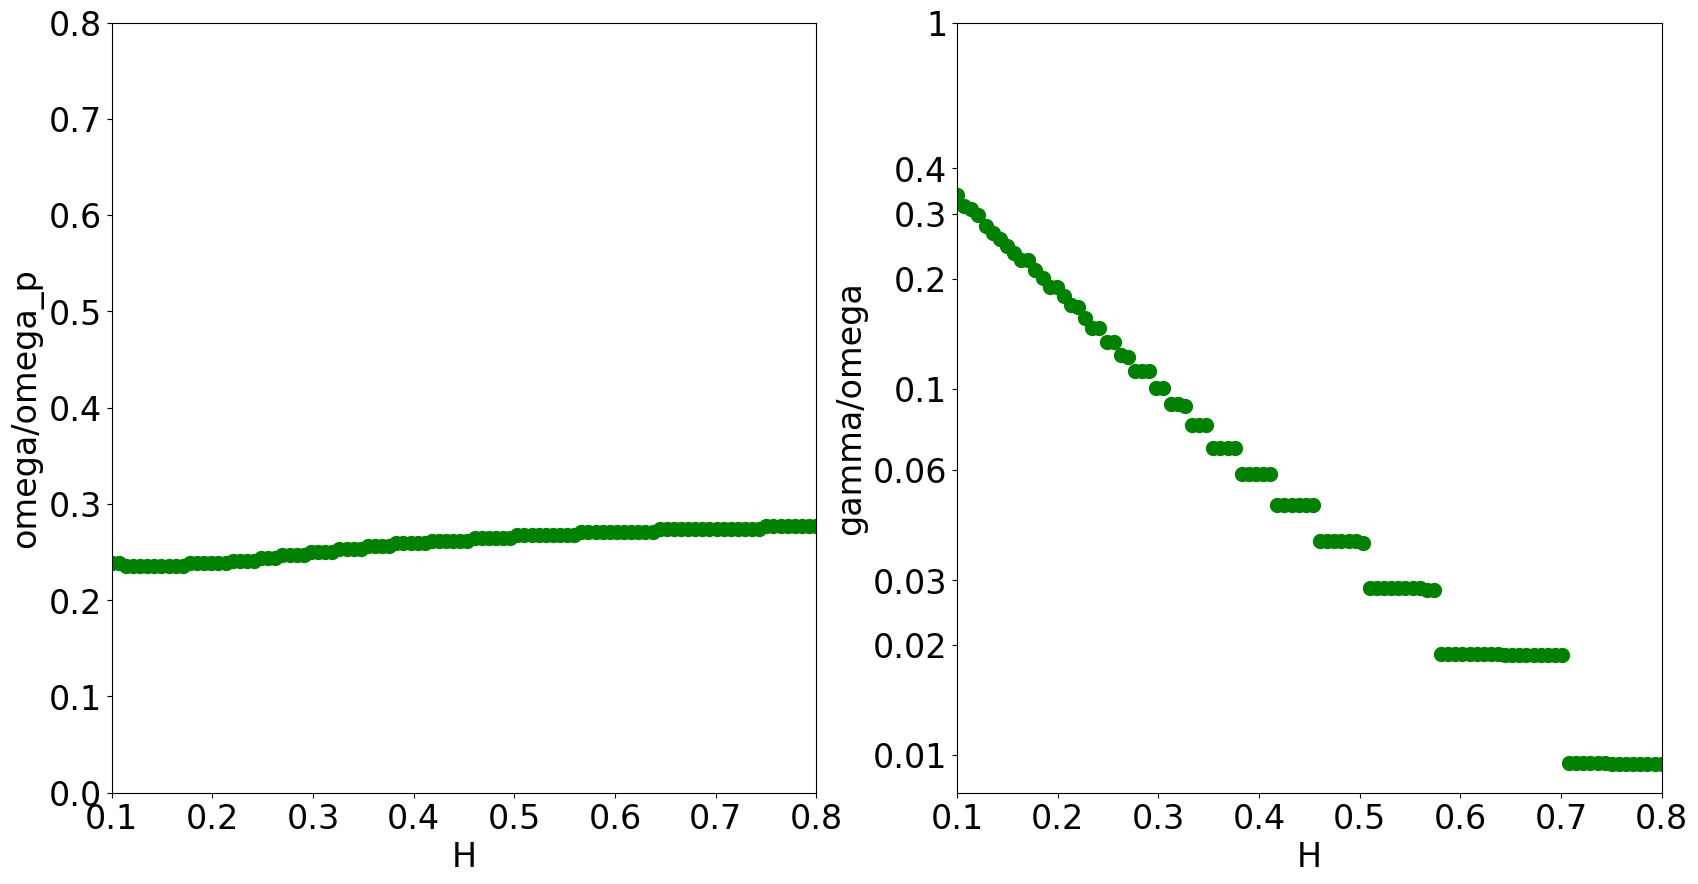

In [335]:
color = "green"
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x], omega_over_omega_ps_real[y], color=color, s=100);
ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8);

ax2.scatter(Hs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100);
ax2.set_xlabel("H")
ax2.set_yticks([log(0.01), log(0.02), log(0.03), log(0.06), log(0.1), log(0.2), log(0.3), log(0.4), log(1)], [0.01, 0.02, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4,  1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);
#ax2.set_ylim(log(0.01), log(1));

In [344]:
K = 100
N = 200
gamma_e = 0
optimized_gammas = np.zeros(Hs[x].shape[0])
optimized_omegas = np.zeros(Hs[x].shape[0])
optimized_Hs = np.zeros(Hs[x].shape[0])
for idx in range(0, Hs[x].shape[0]):
    if (idx % 10) == 0: 
        print(idx)
    H = Hs[x[idx]]
    starting_omega = omega_over_omega_ps_real[y[idx]]
    starting_gamma = gammas[x[idx], y[idx]]

    omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
    omega_over_omega_ps_imag_zoom = linspace(0.2, 2, N) * starting_gamma
    omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)

    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * l * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * l * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    max_idx = scattering_amplitudes.argmax()
    row, col = unravel_index(max_idx, (N, N))
    optimized_Hs[idx] = H
    optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
    optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

0
10
20
30
40
50
60
70
80
90


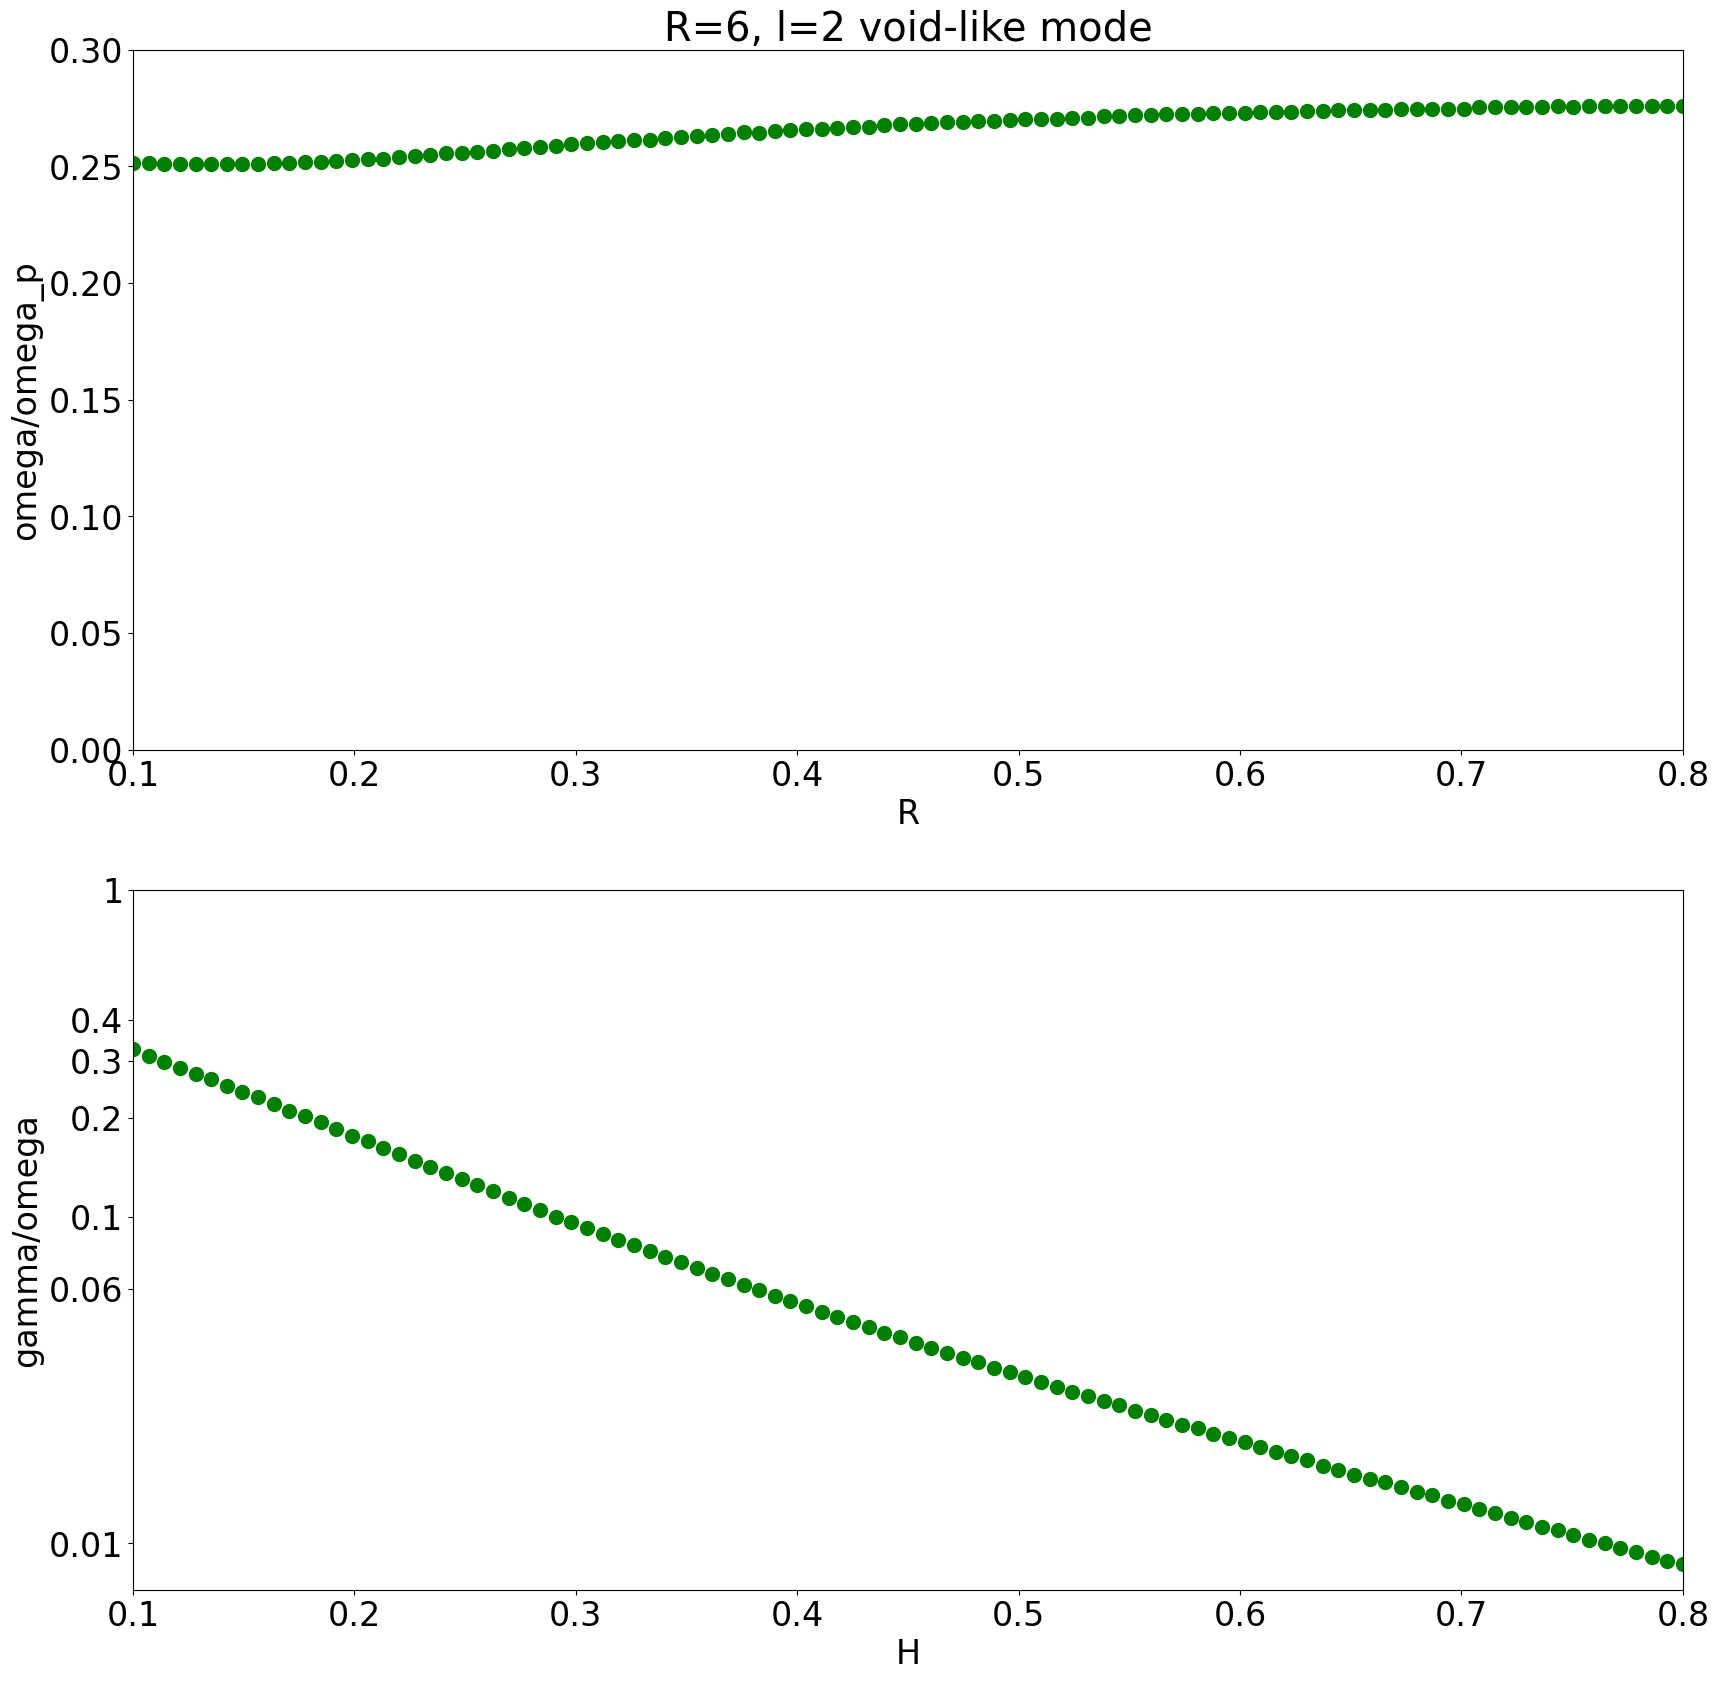

In [346]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
color = "green"
ax1.scatter(optimized_Hs, optimized_omegas, s=100, color=color)
ax2.scatter(optimized_Hs, log(optimized_gammas/optimized_omegas), s=100, color=color)
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.3);
ax2.set_yticks([log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(0.4), log(1)], [0.01, 0.06, 0.1, 0.2, 0.3, 0.4, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("H")
ax2.set_xlim(0.1, 0.8);
#ax2.set_ylim(log(0.01), log(1));
ax1.set_title("R=6, l=2 void-like mode");

## Now we look at the lowest mode 

In [348]:
x, y = np.where(heatmap_data > 10) # Find where the modes are 
first_mode_idxs = np.where((omega_over_omega_ps_real[y] < 0.2)) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

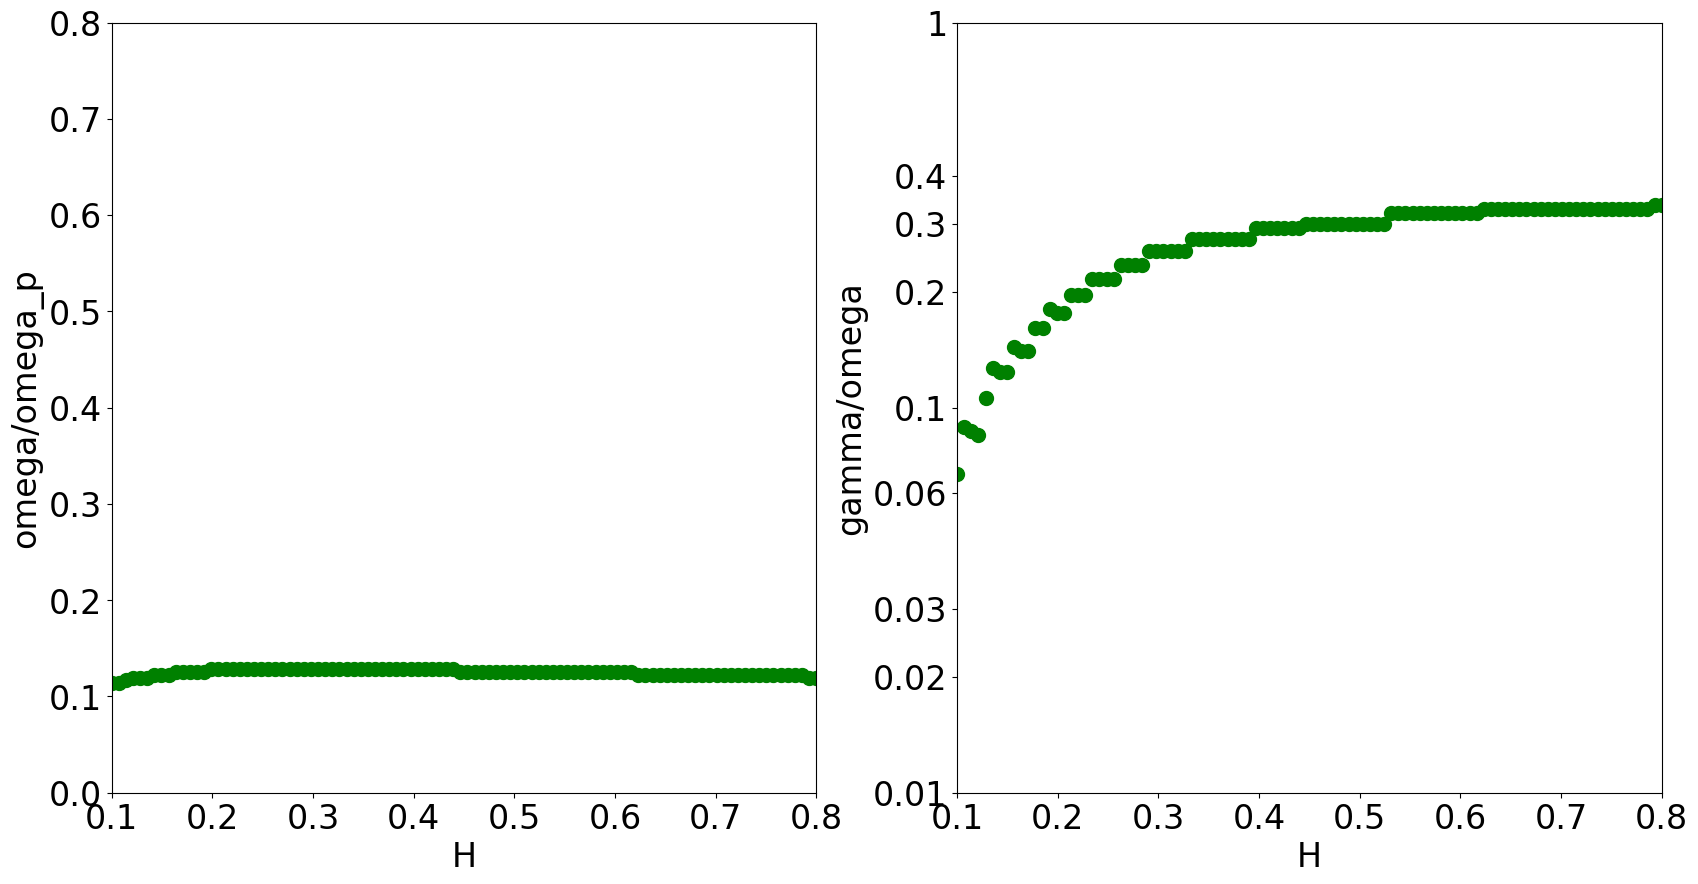

In [349]:
color = "green"
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x], omega_over_omega_ps_real[y], color=color, s=100);
ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8);

ax2.scatter(Hs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100);
ax2.set_xlabel("H")
ax2.set_yticks([log(0.01), log(0.02), log(0.03), log(0.06), log(0.1), log(0.2), log(0.3), log(0.4), log(1)], [0.01, 0.02, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4,  1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);
#ax2.set_ylim(log(0.01), log(1));

In [352]:
K = 100
N = 100
gamma_e = 0
optimized_gammas = np.zeros(Hs[x].shape[0])
optimized_omegas = np.zeros(Hs[x].shape[0])
optimized_Hs = np.zeros(Hs[x].shape[0])
for idx in range(0, Hs[x].shape[0]):
    if (idx % 10) == 0: 
        print(idx)
    H = Hs[x[idx]]
    starting_omega = omega_over_omega_ps_real[y[idx]]
    starting_gamma = gammas[x[idx], y[idx]]

    omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
    omega_over_omega_ps_imag_zoom = linspace(0.2, 2, N) * starting_gamma
    omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)

    epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
    kR = R * l * omega_over_omega_ps
    previous_coefficients = np.array([1, 1])
    
    next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
    kR =  (H+R) * l * omega_over_omega_ps
    next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    max_idx = scattering_amplitudes.argmax()
    row, col = unravel_index(max_idx, (N, N))
    optimized_Hs[idx] = H
    optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
    optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

0
10
20
30
40
50
60
70
80
90


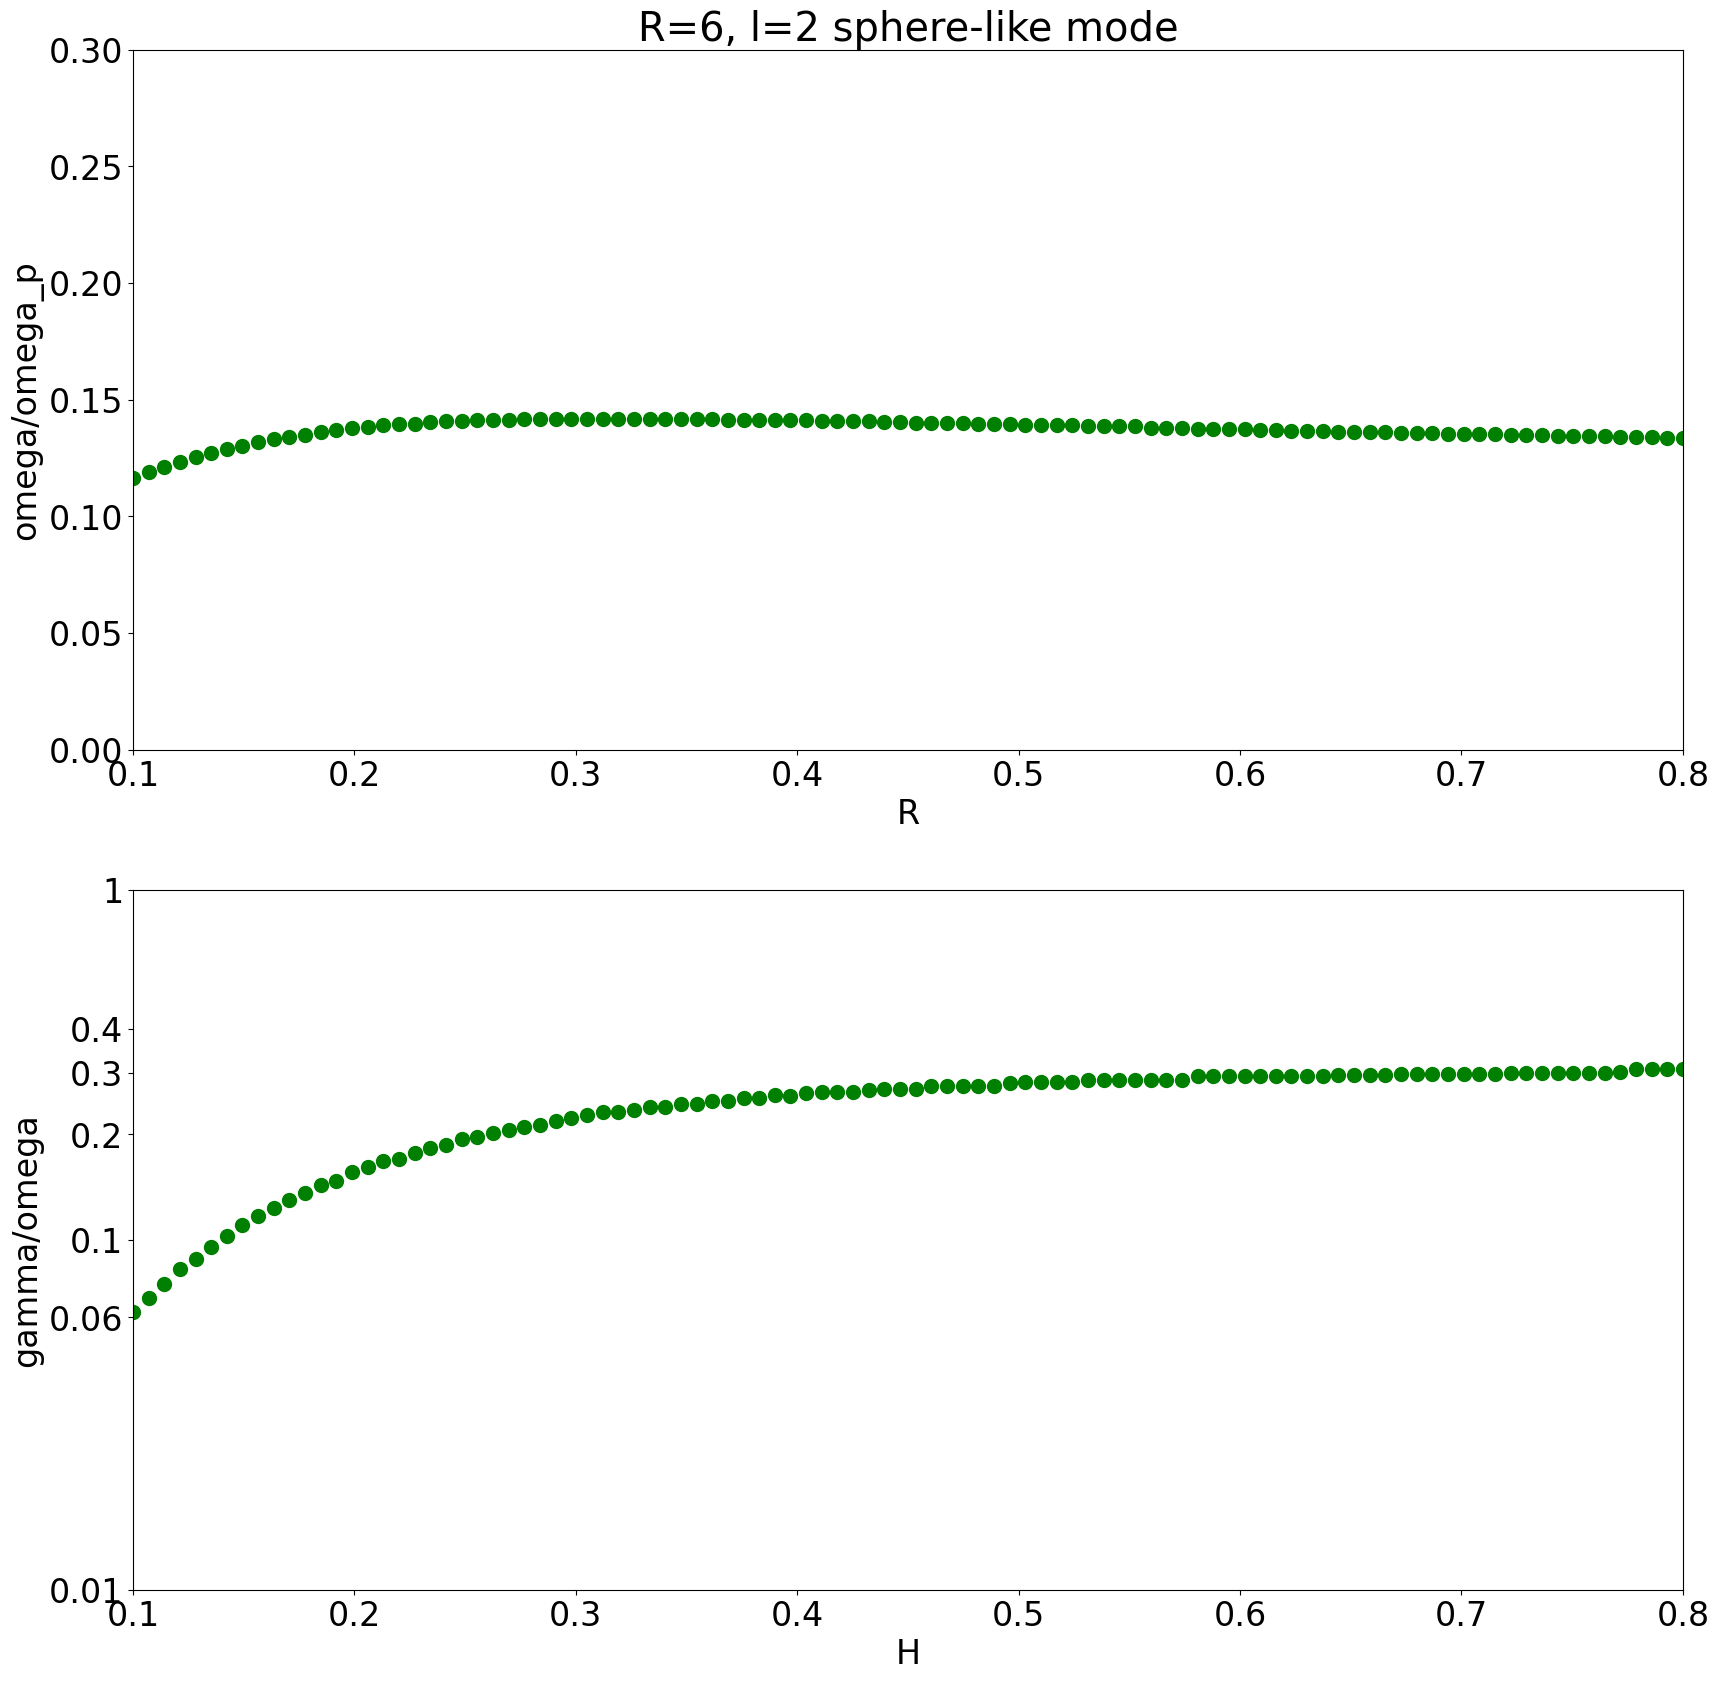

In [353]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
color = "green"
ax1.scatter(optimized_Hs, optimized_omegas, s=100, color=color)
ax2.scatter(optimized_Hs, log(optimized_gammas/optimized_omegas), s=100, color=color)
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.3);
ax2.set_yticks([log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(0.4), log(1)], [0.01, 0.06, 0.1, 0.2, 0.3, 0.4, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("H")
ax2.set_xlim(0.1, 0.8);
#ax2.set_ylim(log(0.01), log(1));
ax1.set_title("R=6, l=2 sphere-like mode");

# We now compare this to what we would get using Equation 2 of the paper (paper_method function)

In [412]:
K = 100
N = 200
l = 2
R = 6
Hs = linspace(0.1, 0.8, K) # Range of Rs (normalized value of b) used in the paper
omega_over_omega_ps_real = linspace(0.01, 0.4, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 0.5, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gamma_e = 0
gammas = np.zeros((K, N))
heatmap_data = np.zeros((K, N))
for (H_idx, H) in enumerate(Hs):
    if (H_idx % 10) == 0:
        print(H_idx)
    epsilons = gold_drude(omega_over_omega_ps, gamma_e=gamma_e)
    A = np.abs(paper_method(l, epsilons, R*l, H*l, omega_over_omega_ps))
    heatmap_data[H_idx, :] =  A.min(axis=1) # maximum across all imaginary values for the frequency
    gammas[H_idx, :] = omega_over_omega_ps_imag[A.argmin(axis=1)]

0
10
20
30
40
50
60
70
80
90


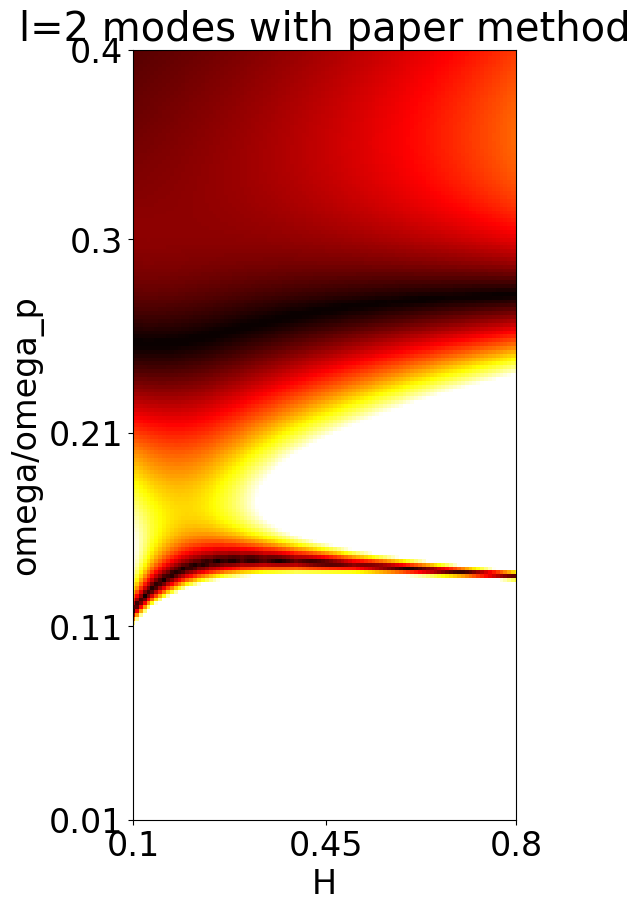

In [453]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xticks([0, K/2, K-1], Hs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/4, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/4), round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("H")
ax.set_ylabel("omega/omega_p");
ax.set_title(f"l=2 modes with paper method");
plt.imshow(heatmap_data.T, origin="lower", cmap="hot", vmin=0.01, vmax=1);

In [450]:
x, y = np.where(heatmap_data < 0.05) # Find where the modes are 
#first_mode_idxs = np.where(omega_over_omega_ps_real[y] < 0.2) # Indices for the lowest mode
first_mode_idxs = np.where((omega_over_omega_ps_real[y] < 0.3) & (omega_over_omega_ps_real[y] > 0.23)) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

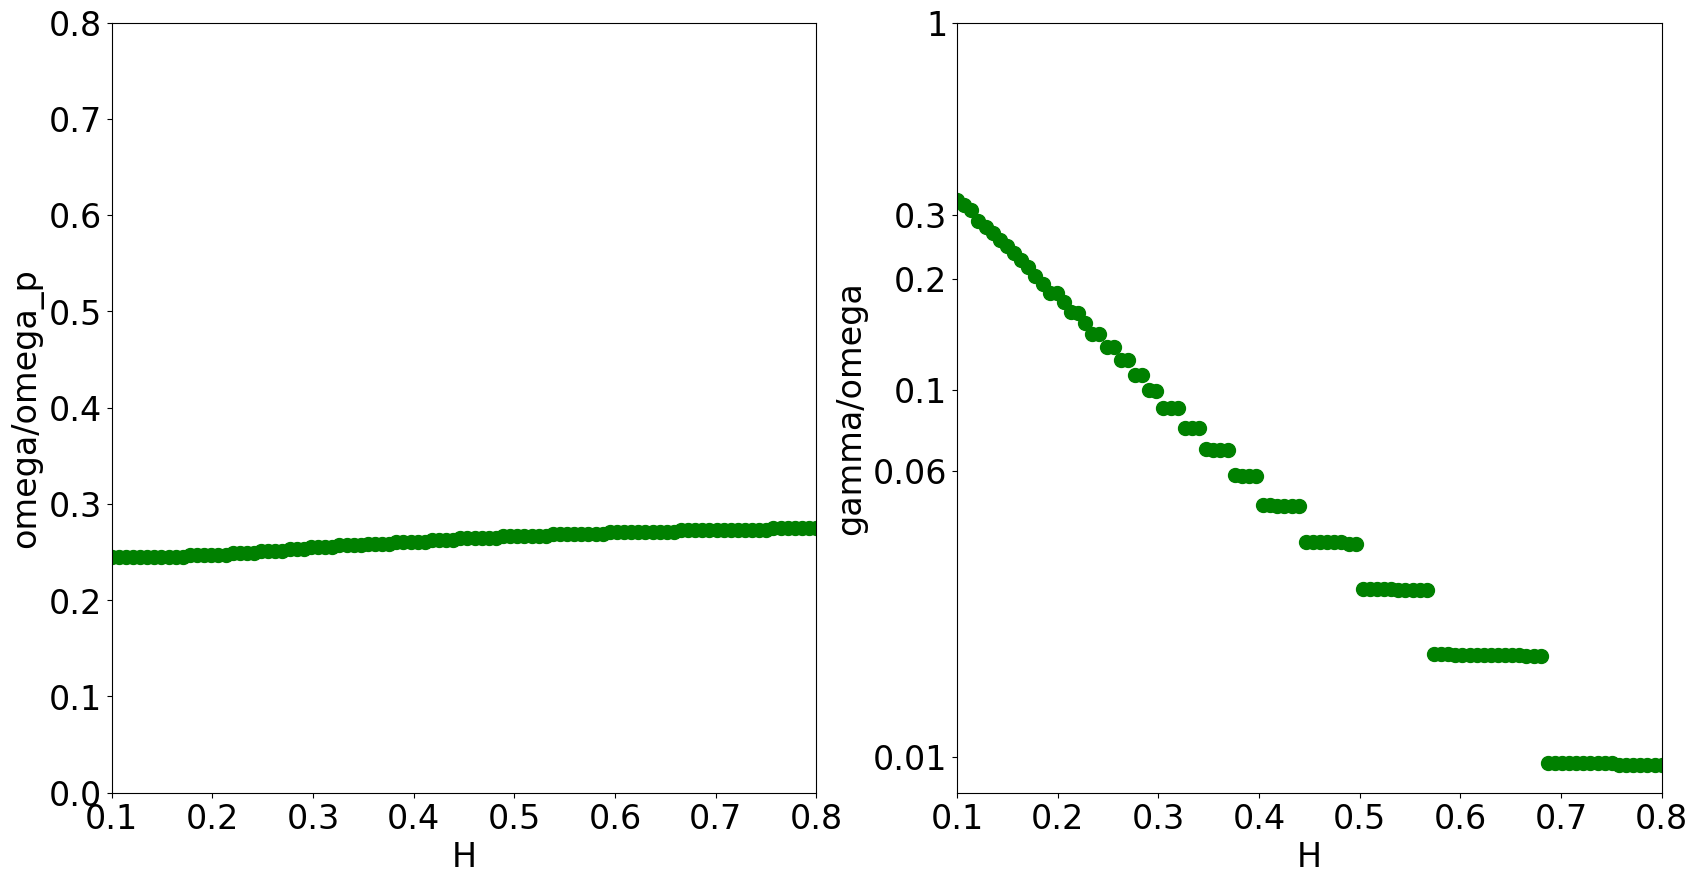

In [451]:
color = "green"
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x], omega_over_omega_ps_real[y], color=color, s=100);
ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8);

ax2.scatter(Hs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100);
ax2.set_xlabel("H")
ax2.set_yticks([log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(1)], [0.01, 0.06, 0.1, 0.2, 0.3, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);
#ax2.set_ylim(log(0.01), log(1));

# In order to calculate for $l=3$, we use a modified version of the paper method. We express all Bessel functions of the first kind as Hankel functions. In addition, to avoid divergences, we analytically mutiply the exponentials in the Hankel functions before numerically evaluating them. 

In [454]:
# h_3^1(x) without e^{ix} term
def analytic_h31(x):
    return -1j*(15/x**4-6/x**2)-(15/x**3-1/x)
# h_3^2(x) without e^{-ix} term
def analytic_h32(x):
    return 1j*(15/x**4-6/x**2)-(15/x**3-1/x)
# (xh_3^1(x))' without e^{ix} term
def analytic_h31_derivative(x):
    return 1j*(45/x**4-21/x**2+1)+(45/x**3-6/x)
def analytic_h32_derivative(x):
    return -1j*(45/x**4-21/x**2+1)+(45/x**3-6/x)

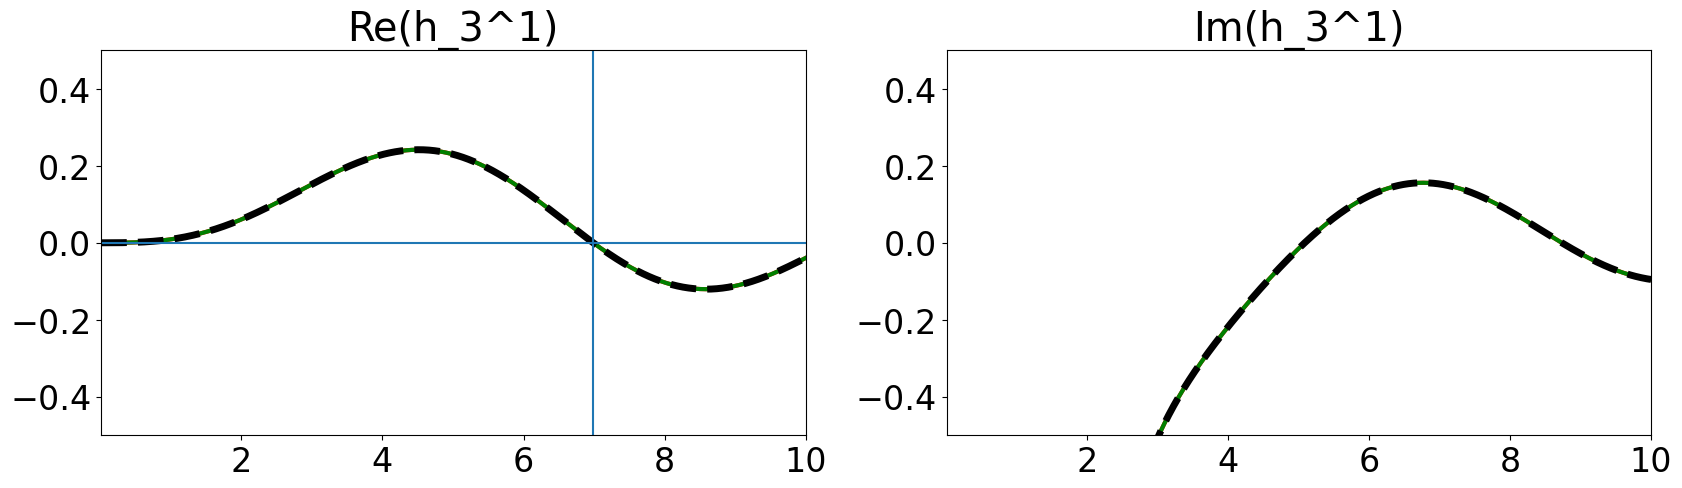

In [468]:
N = 1000
x = linspace(0.01, 10, N)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
ax1.plot(x, (analytic_h31(x)*exp(1j*x)).real, color="red", linewidth=3)
ax1.plot(x, (analytic_h32(x)*exp(-1j*x)).real, color="green", linewidth=3)

ax1.plot(x, hl1(3, x).real, linestyle="dashed", linewidth=5, color="black")
ax1.vlines([6.98793], -10, 10)
ax1.hlines([0], 0.01, 10)
ax1.set_xlim(x.min(), x.max())
ax1.set_ylim(-0.5, 0.5);
ax1.set_title("Re(h_3^1)")
ax2.plot(x, (analytic_h31(x)*exp(1j*x)).imag, color="red", linewidth=3)
ax2.plot(x, -(analytic_h32(x)*exp(-1j*x)).imag, color="green", linewidth=3)
ax2.set_title("Im(h_3^1)")
ax2.plot(x, hl1(3, x).imag, linestyle="dashed", linewidth=5, color="black")
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(-0.5, 0.5);

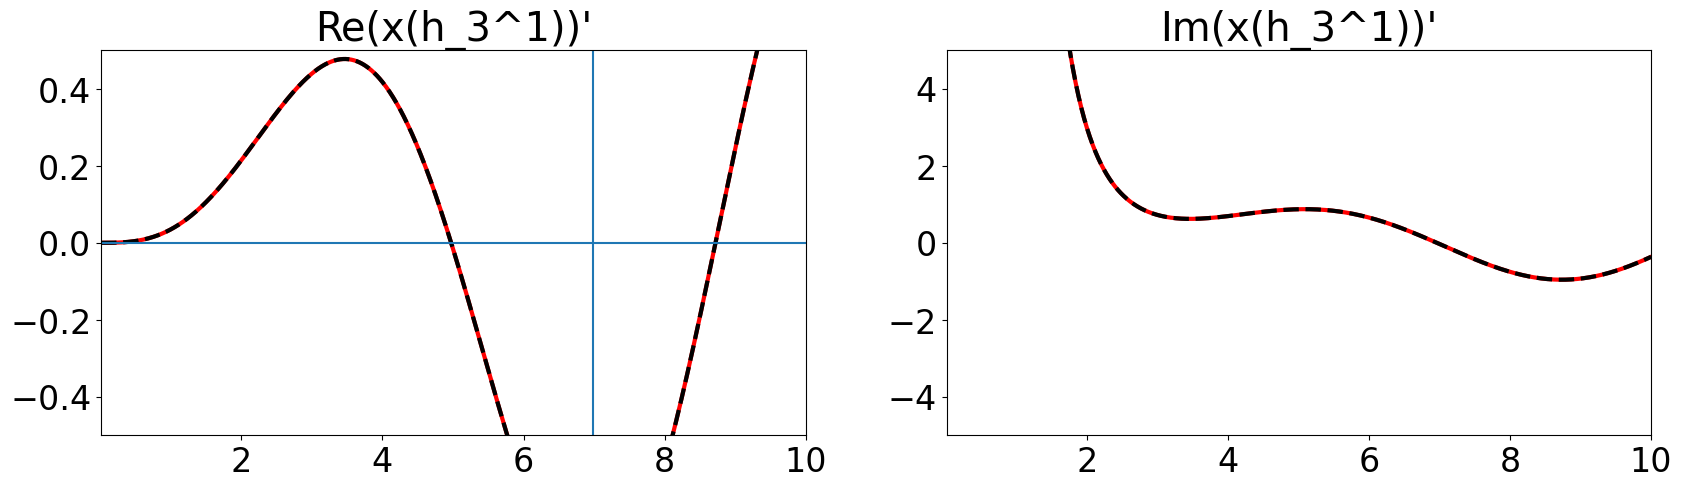

In [469]:
N = 1000
x = linspace(0.01, 10, N)
anal_derivative = analytic_h31_derivative(x)
scipy_derivative = hl1(3, x) + x*hl1prime(3, x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
ax1.plot(x, (anal_derivative*exp(1j*x)).real, color="red", linewidth=3)

ax1.plot(x, scipy_derivative.real, linestyle="dashed", linewidth=3, color="black")
ax1.vlines([6.98793], -10, 10)
ax1.hlines([0], 0.01, 10)
ax1.set_title("Re(x(h_3^1))'")
ax1.set_xlim(x.min(), x.max())
ax1.set_ylim(-0.5, 0.5);

ax2.plot(x, (anal_derivative*exp(1j*x)).imag, color="red", linewidth=3)
ax2.set_title("Im(x(h_3^1))'")
ax2.plot(x, scipy_derivative.imag, linestyle="dashed", linewidth=3, color="black")
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(-5, 5);

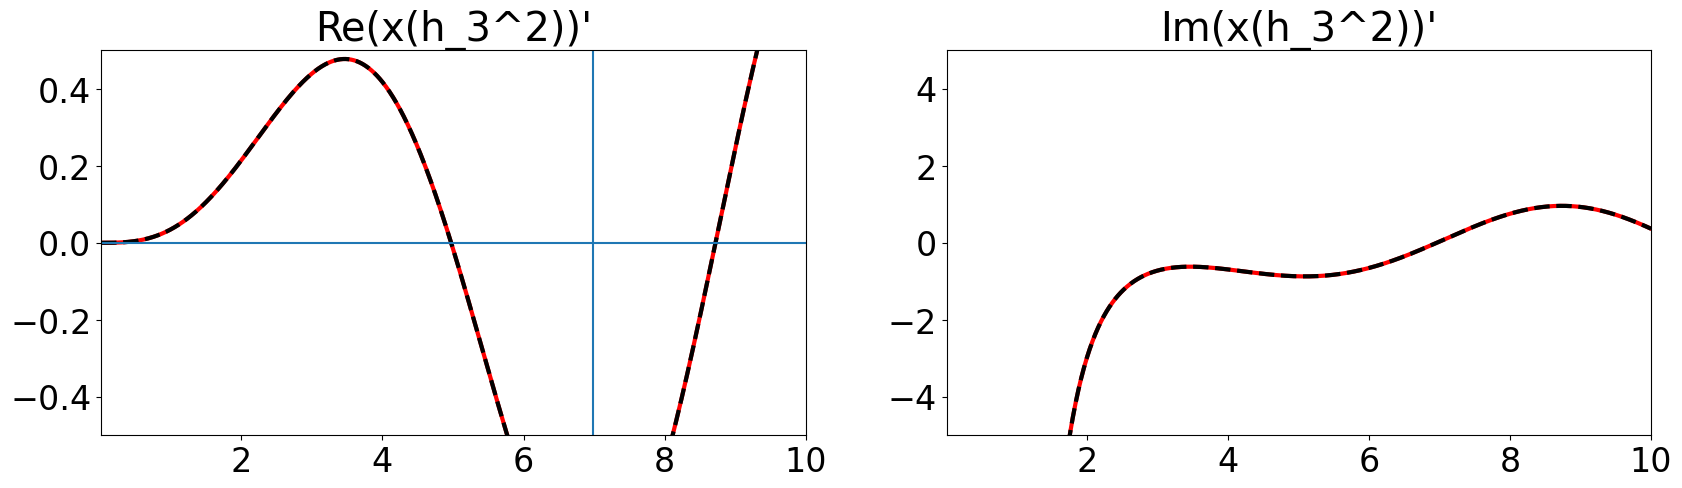

In [470]:
N = 1000
x = linspace(0.01, 10, N)
anal_derivative = analytic_h32_derivative(x)
scipy_derivative = hl2(3, x) + x*hl2prime(3, x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
ax1.plot(x, (anal_derivative*exp(-1j*x)).real, color="red", linewidth=3)

ax1.plot(x, scipy_derivative.real, linestyle="dashed", linewidth=3, color="black")
ax1.vlines([6.98793], -10, 10)
ax1.hlines([0], 0.01, 10)
ax1.set_xlim(x.min(), x.max())
ax1.set_ylim(-0.5, 0.5);
ax1.set_title("Re(x(h_3^2))'")

ax2.plot(x, (anal_derivative*exp(-1j*x)).imag, color="red", linewidth=3)
ax2.set_title("Im(x(h_3^2))'")
ax2.plot(x, scipy_derivative.imag, linestyle="dashed", linewidth=3, color="black")
ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(-5, 5);

In [471]:
def paper_method_2(epsilon, R, H, omega):
    rho_b = R*omega
    rho_a = (R+H)*omega
    eta_b = sqrt(epsilon)*rho_b
    eta_a = sqrt(epsilon)*rho_a

    rho_b_jlprime = spherical_jn(3, rho_b) + rho_b*spherical_jn(3, rho_b, derivative=True)

    rho_b_hl2prime = hl2(3, rho_b) + rho_b*hl2prime(3, rho_b)
    
    eta_b_hl2 = analytic_h32(eta_b)
    eta_a_hl2 = analytic_h32(eta_a)
    
    eta_b_hl1 = analytic_h31(eta_b)
    eta_a_hl1 = analytic_h31(eta_a)

    eta_b_hl2prime = analytic_h32_derivative(eta_b)
    eta_a_hl2prime = analytic_h32_derivative(eta_a)

    rho_a_hlprime = hl1(3, rho_a) + rho_a*hl1prime(3, rho_a)
    eta_b_hlprime = analytic_h31_derivative(eta_b)
    eta_a_hlprime = analytic_h31_derivative(eta_a)
    
    D_l = eta_b_hl2prime*eta_a_hl1*exp(1j*(eta_a-eta_b)) - eta_b_hlprime*eta_a_hl2*exp(-1j*(eta_a-eta_b))
    
    C_l = eta_b_hl2*eta_a_hl1*exp(1j*(eta_a-eta_b)) - eta_a_hl2*eta_b_hl1*exp(-1j*(eta_a-eta_b)) 
    
    B_l = eta_b_hl2prime * eta_a_hlprime*exp(1j*(eta_a-eta_b)) - eta_a_hl2prime * eta_b_hlprime*exp(-1j*(eta_a-eta_b))
    A_l = eta_b_hl2*eta_a_hlprime*exp(1j*(eta_a-eta_b)) - eta_b_hl1*eta_a_hl2prime * exp(-1j*(eta_a-eta_b))

    beta_l = epsilon * (epsilon * rho_b_jlprime * C_l - spherical_jn(l, rho_b) * D_l)
    alpha_l = epsilon * rho_b_jlprime * A_l - spherical_jn(3, rho_b) * B_l

    LHS = hl1(l, rho_a) * alpha_l
    RHS = beta_l * rho_a_hlprime
    return LHS - RHS

In [553]:
K = 100
N = 600
l = 3
R = 6
Hs = linspace(0.1, 0.8, K) # Range of Rs (normalized value of b) used in the paper
omega_over_omega_ps_real = linspace(0.05, 0.3, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 0.5, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gamma_e = 0
gammas = np.zeros((K, N))
heatmap_data = np.zeros((K, N))
for (H_idx, H) in enumerate(Hs):
    if (H_idx % 10) == 0:
        print(H_idx)
    epsilons = gold_drude(omega_over_omega_ps, gamma_e=gamma_e)
    A = np.abs(paper_method_2(epsilons, R*l, H*l, omega_over_omega_ps))
    heatmap_data[H_idx, :] =  A.min(axis=1) # maximum across all imaginary values for the frequency
    gammas[H_idx, :] = omega_over_omega_ps_imag[A.argmin(axis=1)]

0
10
20
30
40
50
60
70
80
90


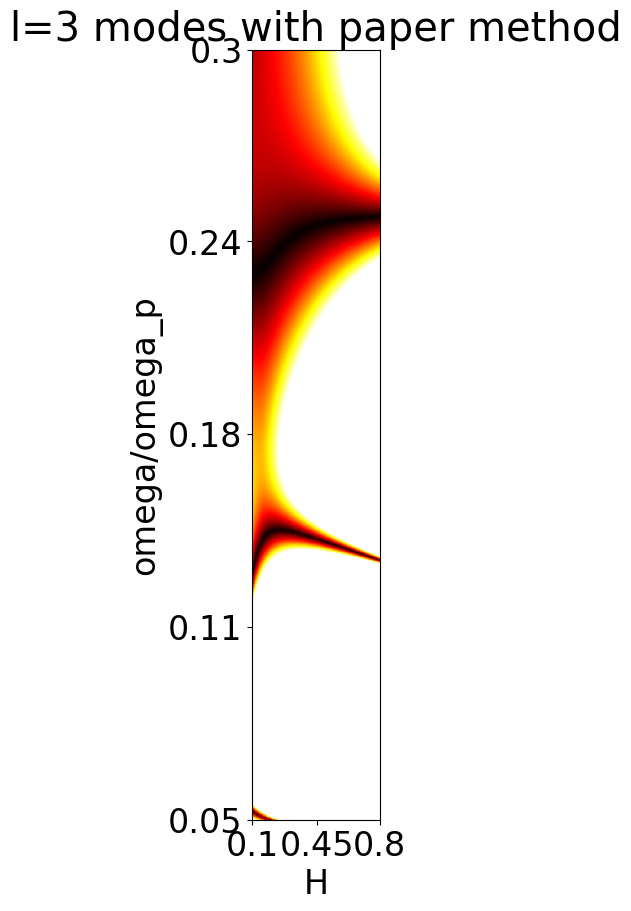

In [554]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xticks([0, K/2, K-1], Hs[[0, round(K/2), K-1]].round(2))
ax.set_yticks([0, N/4, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/4), round(N/2), round(3*N/4), N-1]].round(2))
ax.set_xlim(0, K-1)
ax.set_ylim(0, N-1);
ax.set_xlabel("H")
ax.set_ylabel("omega/omega_p");
ax.set_title(f"l=3 modes with paper method");
plt.imshow(heatmap_data.T, origin="lower", cmap="hot", vmin=0.01, vmax=1);

In [555]:
x, y = np.where(heatmap_data < 0.05) # Find where the modes are 
first_mode_idxs = np.where(omega_over_omega_ps_real[y] > 0.2) # Indices for the lowest mode
#first_mode_idxs = np.where((omega_over_omega_ps_real[y] < 0.18) & (omega_over_omega_ps_real[y] > 0.11)) # Indices for the lowest mode
x = x[first_mode_idxs]
y = y[first_mode_idxs]
filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
x = x[filter_idxs]
y = y[filter_idxs]

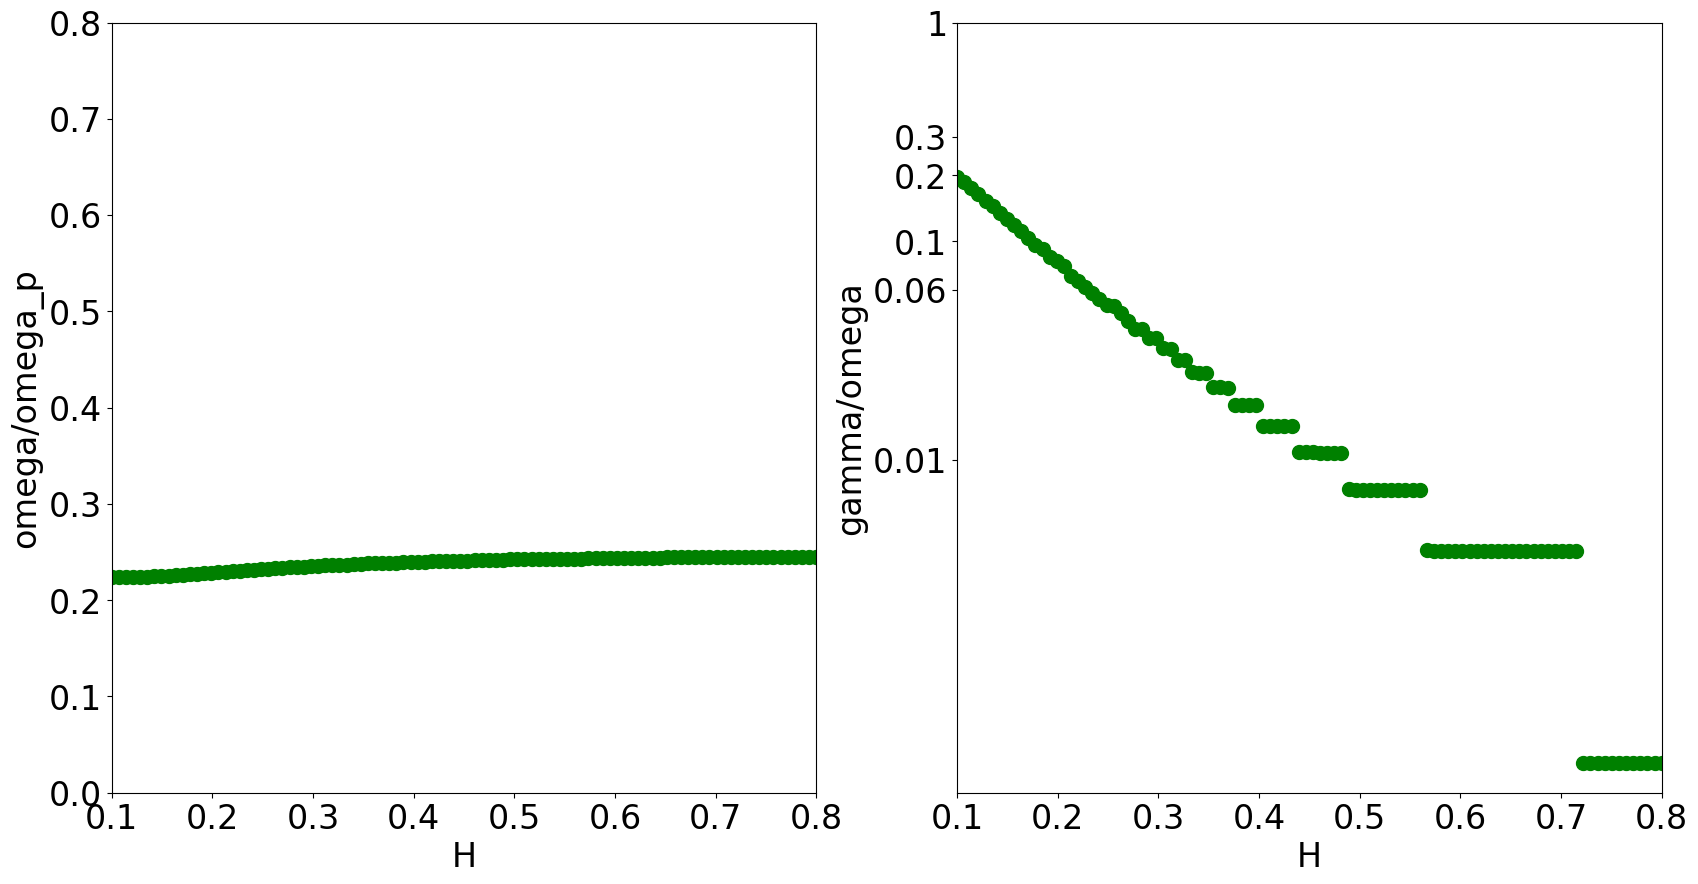

In [556]:
color = "green"
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(Hs[x], omega_over_omega_ps_real[y], color=color, s=100);
ax1.set_xlabel("H")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.8);

ax2.scatter(Hs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100);
ax2.set_xlabel("H")
ax2.set_yticks([log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(1)], [0.01, 0.06, 0.1, 0.2, 0.3, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(0.1, 0.8);

## We zoom in on the mode near $\omega/\omega_p=0.2$

In [564]:
K = 100
N1 = 100
N2 = 100
gamma_e = 0
optimized_gammas = np.zeros(Hs[x].shape[0])
optimized_omegas = np.zeros(Hs[x].shape[0])
optimized_Hs = np.zeros(Hs[x].shape[0])
for idx in range(0, Hs[x].shape[0]):
    if (idx % 10) == 0: 
        print(idx)
    H = Hs[x[idx]]
    starting_omega = omega_over_omega_ps_real[y[idx]]
    starting_gamma = gammas[x[idx], y[idx]]

    omega_over_omega_ps_real_zoom = linspace(0.99, 1.01, N1) * starting_omega
    omega_over_omega_ps_imag_zoom = linspace(0.1, 1.5, N2) * max(starting_gamma, 0.00053048) 
    omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N1, 1)).repeat(N2, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N2)).repeat(N1, axis=0)

    epsilons = gold_drude(omega_over_omega_ps, gamma_e=gamma_e)
    A = np.abs(paper_method_2(epsilons, R*l, H*l, omega_over_omega_ps))

    max_idx = A.argmin()
    row, col = unravel_index(max_idx, (N1, N2))
    optimized_Hs[idx] = H
    optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
    optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]

0
10
20
30
40
50
60
70
80
90


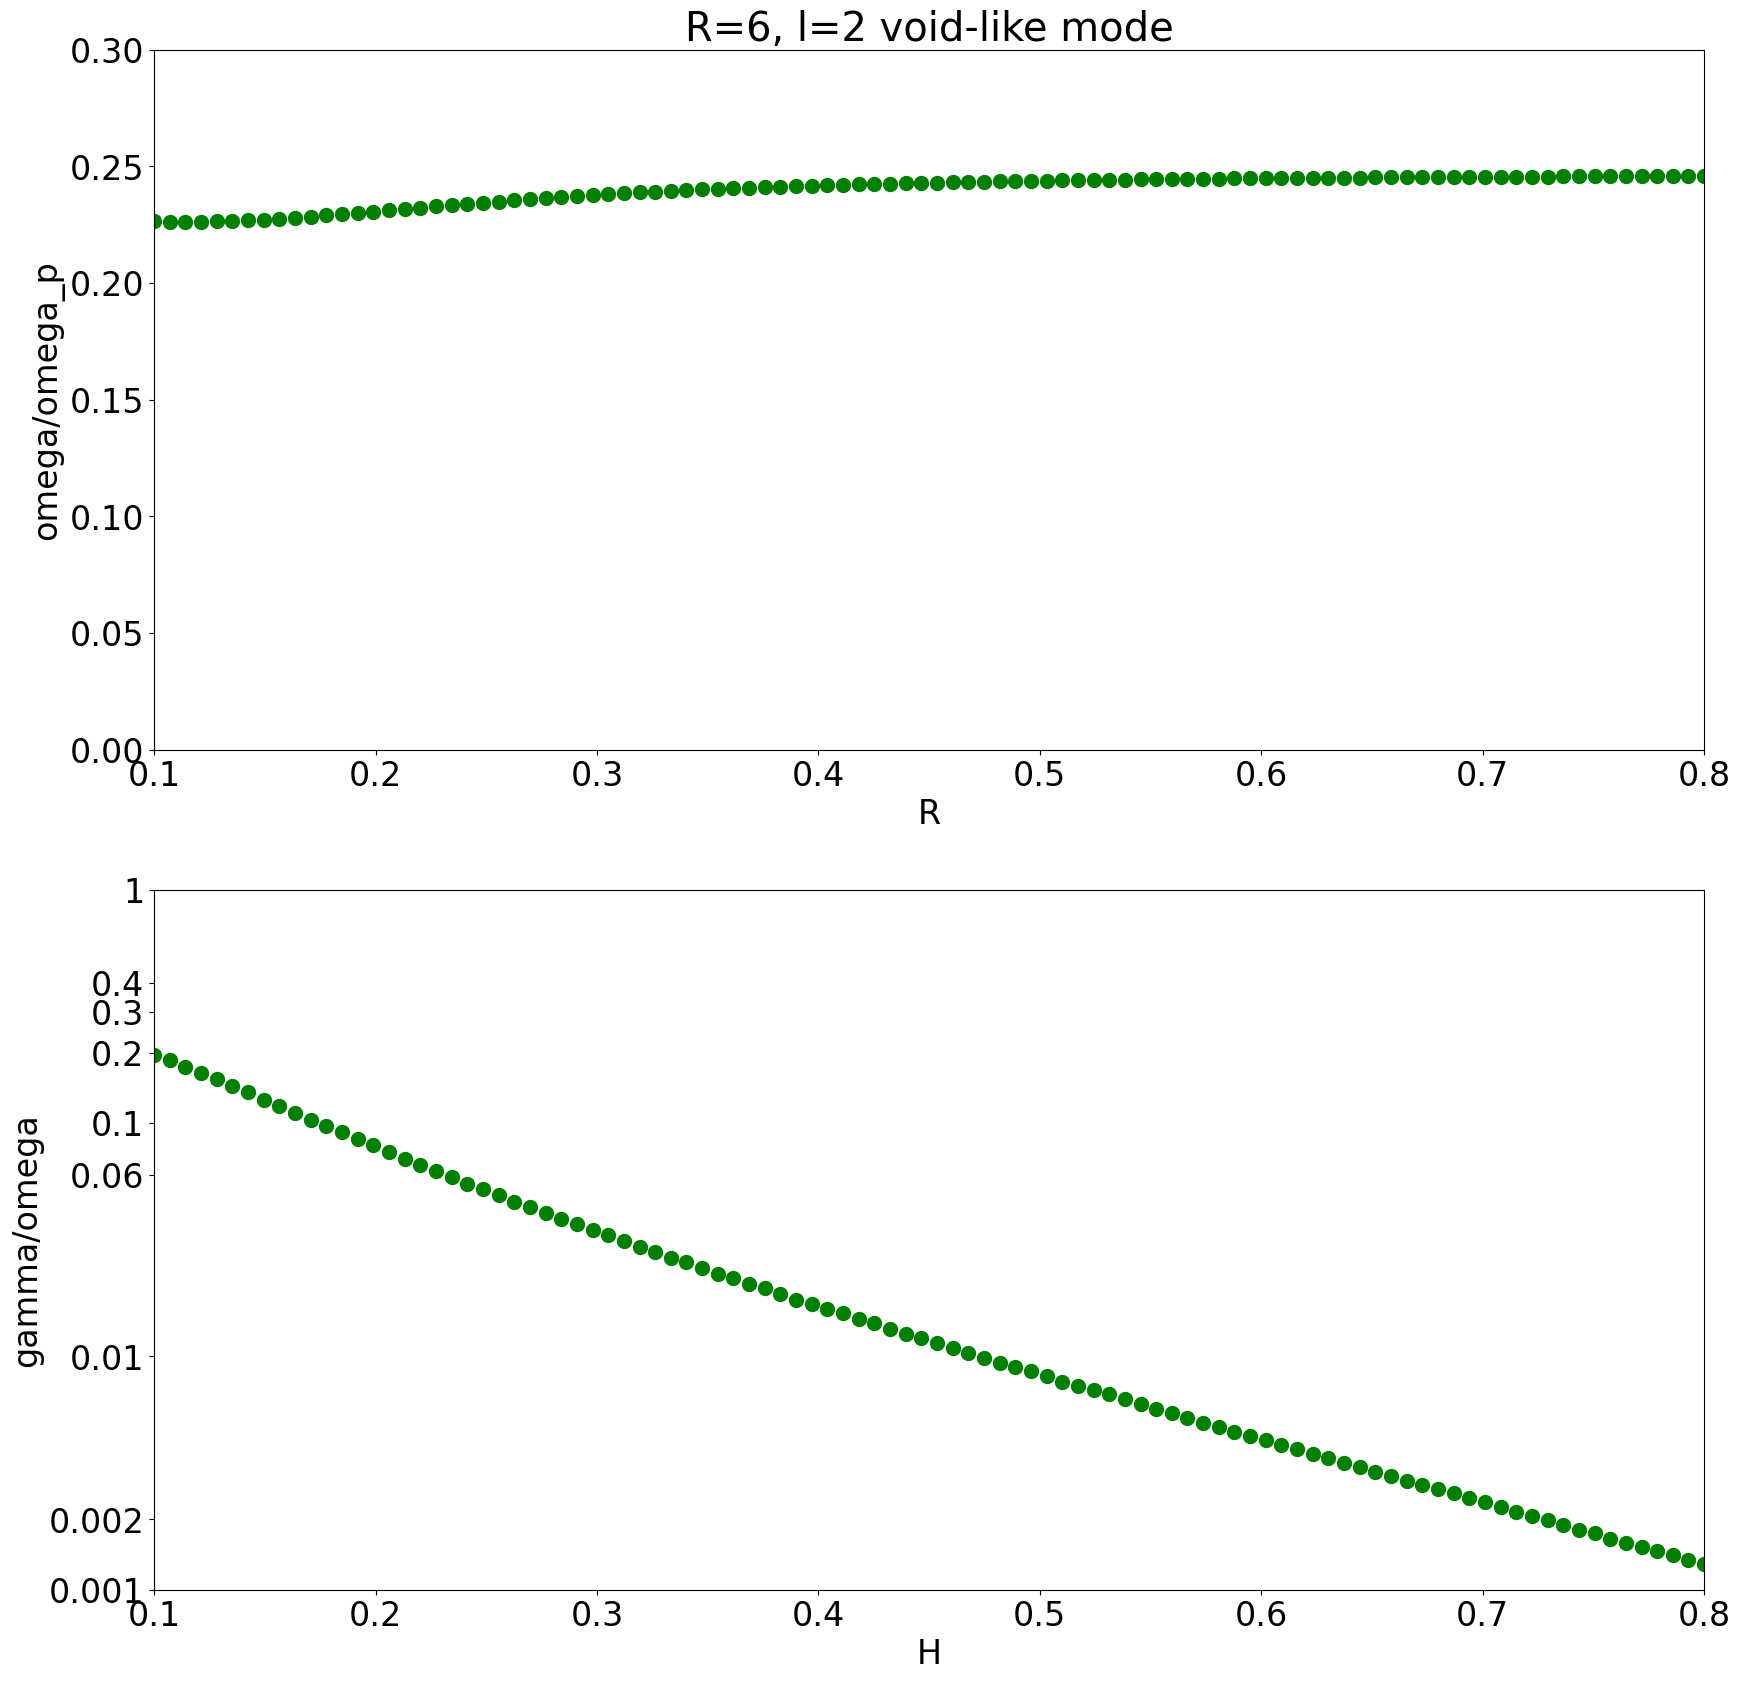

In [569]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
color = "green"
ax1.scatter(optimized_Hs, optimized_omegas, s=100, color=color)
ax2.scatter(optimized_Hs, log(optimized_gammas/optimized_omegas), s=100, color=color)
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(0.1, 0.8);
ax1.set_ylim(0, 0.3);
ax2.set_yticks([log(0.001), log(0.002), log(0.01), log(0.06), log(0.1), log(0.2), log(0.3), log(0.4), log(1)], [0.001, 0.002, 0.01, 0.06, 0.1, 0.2, 0.3, 0.4, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("H")
ax2.set_xlim(0.1, 0.8);
ax2.set_ylim(log(0.001), log(1));
ax1.set_title("R=6, l=2 void-like mode");

# In another approximation, the nanoshell is approximated as a coating of finite surface conductivity $i\sigma(\omega)/(\omega\varepsilon_0 d)=\varepsilon(\omega)-1\rightarrow g(\omega)(R/H)=\varepsilon(\omega)-1$

In [208]:
R_lindependent = 6
void_upper_lims = [0.4, 0.7, 0.7]
void_lower_lims = [0.2, 0.5, 0.5]

sphere_upper_lims = [0.2, 0.3, 0.3]
sphere_lower_lims = [0.01, 0.2, 0.2]

void_omegas = []
sphere_omegas = []

ls = [1, 2, 3]
epsilon = 1 # The inside and the environment of the nanoshell are taken as vacuum. 
gamma_e = 0 # No Drude scattering. 

K = 100
N = 200
Hs_lindependent = linspace(0.1, 0.8, K)

heatmaps_v_sphere = [] 
heatmaps_v_void = [] 

omega_over_omega_ps_real = linspace(0.01, 0.8, N)# range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.001, 0.5, N)# range of real(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)

for (l_idx, l) in enumerate(ls):
    print("Angular momentum: ", l)
    lower_lim = sphere_lower_lims[l_idx], 
    upper_lim = sphere_upper_lims[l_idx]
    omega_over_omega_ps_real = linspace(lower_lim, upper_lim, N)# range of real(omega)/omega_p
    omega_over_omega_ps_imag = linspace(0.001, 0.5, N)# range of real(omega)/omega_p
    omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
    heatmap = np.zeros((K, N))
    for (H_idx, H_lindependent) in enumerate(Hs_lindependent):
        H = l * H_lindependent
        R = R_lindependent * l 
        g_omegas = (gold_drude(omega_over_omega_ps, gamma_e=gamma_e)-1) * H/R
        kR = R * omega_over_omega_ps
        thin_film_approx = e_r_cpa_denominator(l, kR, epsilon, g_omegas=g_omegas);
        heatmap[H_idx, :] = np.abs(thin_film_approx).min(axis=1)
    heatmaps_v_sphere.append(heatmap)

    lower_lim = void_lower_lims[l_idx], 
    upper_lim = void_upper_lims[l_idx]

    omega_over_omega_ps_real = linspace(lower_lim, upper_lim, N)# range of real(omega)/omega_p
    omega_over_omega_ps_imag = linspace(0.001, 0.5, N)# range of real(omega)/omega_p
    omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)

    heatmap = np.zeros((K, N))
    for (H_idx, H_lindependent) in enumerate(Hs_lindependent):
        H = l * H_lindependent
        R = R_lindependent * l 
        g_omegas = (gold_drude(omega_over_omega_ps, gamma_e=gamma_e)-1) * H/R
        kR = R * omega_over_omega_ps
        thin_film_approx = e_r_cpa_denominator(l, kR, epsilon, g_omegas=g_omegas);
        heatmap[H_idx, :] = np.abs(thin_film_approx).min(axis=1)
    heatmaps_v_void.append(heatmap)

Angular momentum:  1
Angular momentum:  2
Angular momentum:  3


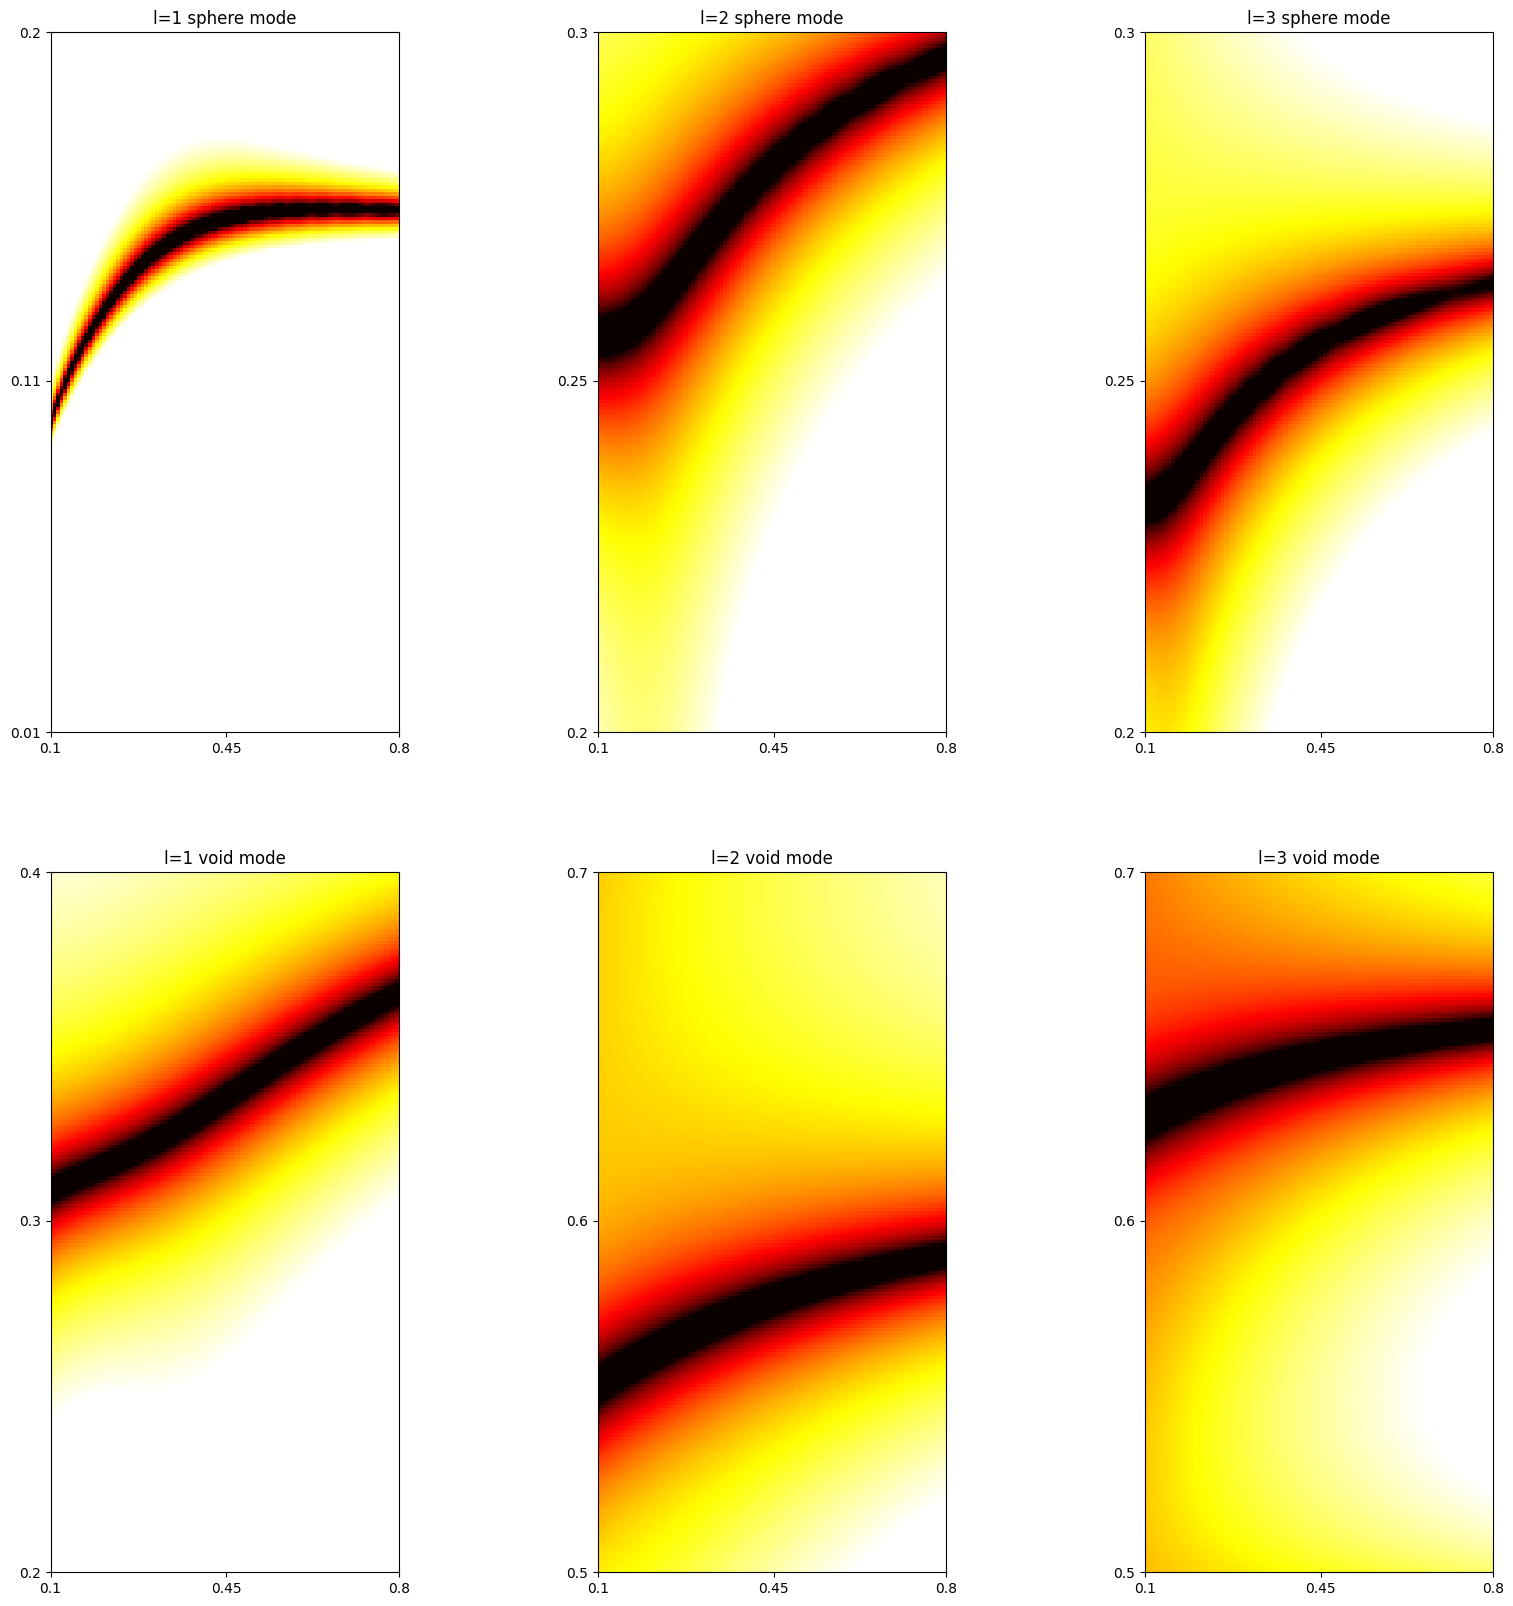

In [277]:
fig, axs = plt.subplots(2, 3, figsize=(20, 20))
for (l_idx, l) in enumerate(ls):
    lower_lim = sphere_lower_lims[l_idx]
    upper_lim = sphere_upper_lims[l_idx]
    omega_over_omega_ps_real = linspace(lower_lim, upper_lim, N)# range of real(omega)/omega_p
    vmin = -3 if l == 1 else -4
    axs[0, l_idx].imshow(log(heatmaps_v_sphere[l_idx].T), origin="lower", cmap="hot", vmin=vmin, vmax=-1)
    axs[0, l_idx].set_xticks([0, K/2, K])
    axs[0, l_idx].set_yticks([0, N/2, N-1], [round(omega_over_omega_ps_real[0], 2), round(omega_over_omega_ps_real[round(N/2)], 2), round(omega_over_omega_ps_real[round(N-1)], 2)])
    axs[0, l_idx].set_xticks([0, K/2, K-1], [round(Hs_lindependent[0], 2), round(Hs_lindependent[round(K/2)], 2), round(Hs_lindependent[round(K-1)], 2)])
    axs[0, l_idx].set_xlim(0, K-1)
    axs[0, l_idx].set_ylim(0, N-1)

    axs[0, l_idx].set_title(f"l={l} sphere mode")
    
    lower_lim = void_lower_lims[l_idx]
    upper_lim = void_upper_lims[l_idx]
    omega_over_omega_ps_real = linspace(lower_lim, upper_lim, N)# range of real(omega)/omega_p

    axs[1, l_idx].imshow(log(heatmaps_v_void[l_idx].T), origin="lower", cmap="hot", vmin=-4, vmax=-1)
    axs[1, l_idx].set_title(f"l={l} void mode")
    axs[1, l_idx].set_xticks([0, K/2, K])
    axs[1, l_idx].set_yticks([0, N/2, N-1], [round(omega_over_omega_ps_real[0], 2), round(omega_over_omega_ps_real[round(N/2)], 2), round(omega_over_omega_ps_real[round(N-1)], 2)])
    axs[1, l_idx].set_xticks([0, K/2, K-1], [round(Hs_lindependent[0], 2), round(Hs_lindependent[round(K/2)], 2), round(Hs_lindependent[round(K-1)], 2)])
    axs[1, l_idx].set_xlim(0, K-1)
    axs[1, l_idx].set_ylim(0, N-1)


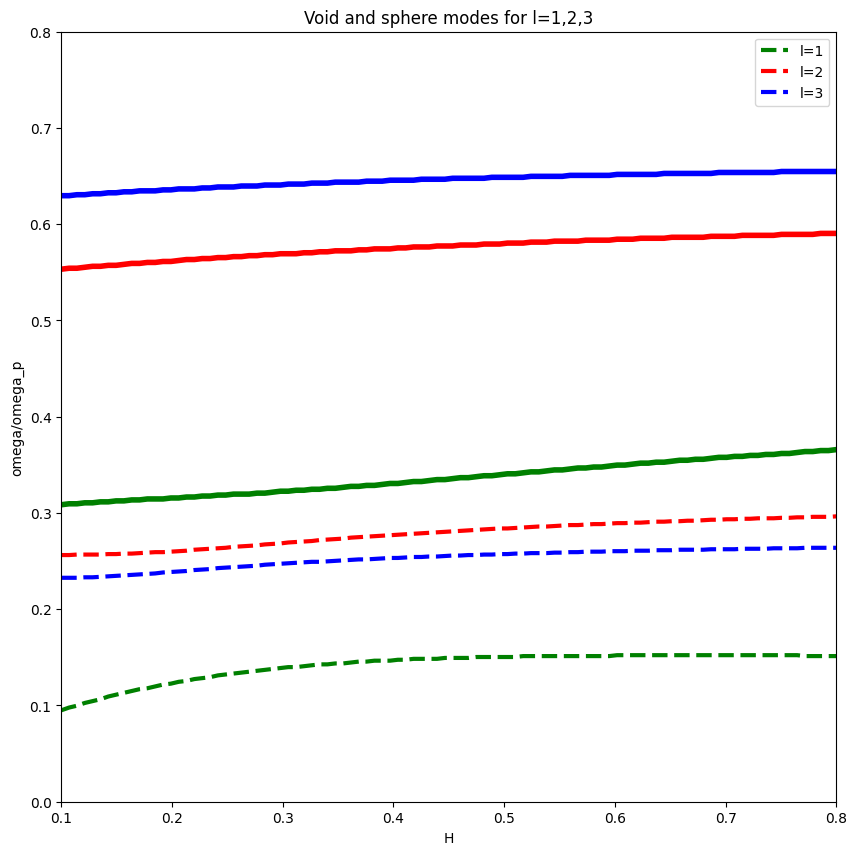

In [292]:
## Plot the void and sphere-like modes for l=1
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
colors = ["green", "red", "blue"]
for (l_idx, l) in enumerate(ls):
    color = colors[l_idx]
    lower_lim = sphere_lower_lims[l_idx]
    upper_lim = sphere_upper_lims[l_idx]
    omega_over_omega_ps_real = linspace(lower_lim, upper_lim, N)# range of real(omega)/omega_p

    mode_idxs = heatmaps_v_sphere[l_idx].argmin(axis=1)
    ax.plot(Hs_lindependent, omega_over_omega_ps_real[mode_idxs], label=f"l={l}", linestyle="dashed", linewidth=3, color=color)
    
    lower_lim = void_lower_lims[l_idx]
    upper_lim = void_upper_lims[l_idx]
    mode_idxs = heatmaps_v_void[l_idx].argmin(axis=1)

    omega_over_omega_ps_real = linspace(lower_lim, upper_lim, N)# range of real(omega)/omega_p
    ax.plot(Hs_lindependent, omega_over_omega_ps_real[mode_idxs], linestyle="solid", linewidth=4, color=color)
ax.set_ylim(0, 0.8)
ax.set_xlim(0.1, 0.8);
ax.set_ylabel("omega/omega_p")
ax.set_xlabel("H")
ax.set_title("Void and sphere modes for l=1,2,3")
ax.legend();